# 06 — Top 1 Selection (객관적 다중 메트릭 + Lexicographic)

> **목적**: BL 156 cfg 중 객관적 절차로 **Top 1 모델을 재산출**합니다.
>
> **배경**: 잠정 Top 1 (`mat_eq_eq_lam_pap`) 의 HOLD_OUT 24m sortino 0.685 (Top 134/153) 부진으로 학습편향 가능성 → 다중 메트릭 + lexicographic 우선순위 + sensitivity test 절차로 재검증.

## 노트북 구성

| § | 단계 | 핵심 산출 |
|---|---|---|
| §0 | 환경 설정 + 데이터 로딩 | `mt_main` (153 main cfg) + `rt` (regime table) |
| §1 | 평가 기준 정의 (16 메트릭, 5 카테고리) | 우선순위 narrative |
| §2 | Universe 교집합 추출 (top 50 ∩ top 50) | N개 후보군 + 산점도 3장 |
| §3 | Hard filter 결정 + 적용 (사용자 합의) | filtered M cfg |
| §4 | Lexicographic 종합 점수 | 최종 정렬표 |
| §5 | Top 10 후보 정밀 분석 | 16 메트릭 heatmap |
| §6 | 안정성 + 견고성 검증 | regime / overfitting / 누적수익 |
| §7 | 위험 분석 | drawdown / sector HHI / 2024-12 |
| §8 | baseline 우월성 검증 | alpha / beta / IR + bootstrap CI |
| §9 | Top 5 → Top 1 결정 | 결정 matrix + narrative |
| §10 | Sensitivity test (견고성) | ε / 우선순위 / sub-period 변경 |

## 평가 메트릭 우선순위 (사용자 합의)

1. **Sortino_TEST** (학습 168m downside risk-adjusted)
2. **MDD** (TEST + HOLD_OUT 별도 산출)
3. **sortino_ir** (3-regime mean / std 안정성)

**보조 분석**: 모든 다른 지표 포함 (Sortino_HO/FULL, Sharpe, CAGR, Calmar, VaR, turnover, eff_n, sector HHI, alpha, **beta**, IR)

## Universe

TEST 구간 기준 **Sortino_TEST top 50 ∩ sortino_ir top 50** 교집합 만 사용.

## 작성

- 작성일: 2026-05-08
- 환경: `.venv` (Python 3.12.4)
- 데이터: 4번째 LSTM 재학습 결과 (192m, 2010-01~2025-12)


## §0. 환경 설정 + 데이터 로딩

In [1]:
# §0-1. imports + 한글 폰트 (CLAUDE.md 표준)
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    import koreanize_matplotlib  # noqa: F401
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore', category=FutureWarning)
sys.path.insert(0, str(Path.cwd()))

# 출력 디렉터리
OUT_DIR = Path('outputs/06_top1')
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'OUT_DIR: {OUT_DIR.resolve()}')
print(f'FIG_DIR: {FIG_DIR.resolve()}')

OUT_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\final\outputs\06_top1
FIG_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\final\outputs\06_top1\figures


In [2]:
# §0-2. master_table + regime_table 로드
from master_table import build_master_table, build_regime_table, REGIMES, EVAL_PERIODS

panel = pd.read_csv('data/monthly_panel.csv', parse_dates=['date'])
rf  = panel[['date','rf_1m']].drop_duplicates('date').set_index('date')['rf_1m']
spy = panel[['date','spy_ret']].drop_duplicates('date').set_index('date')['spy_ret']

mt = build_master_table('results', rf, spy, sort_by='sortino')
print(f'mt: {mt.shape}')

# Quantile variants 제외 (q55, q64, q70)
mt_main = mt[~mt['name'].str.endswith(('_q55','_q64','_q70'))].copy()
assert len(mt_main) == 153, f'expected 153, got {len(mt_main)}'
print(f'mt_main (153 main cfg): {mt_main.shape}')

# Regime table (sortino_ir 포함)
rt = build_regime_table(mt_main, 'results', rf)
print(f'rt: {rt.shape}')
print(f'sortino_ir 컬럼 확인: {"sortino_ir" in rt.columns}')

mt: (156, 41)
mt_main (153 main cfg): (153, 41)


rt: (153, 57)
sortino_ir 컬럼 확인: True


In [3]:
# §0-3. 평가 기간 + 레짐 정보 출력
print("EVAL_PERIODS:")
for label, (s, e) in EVAL_PERIODS.items():
    print(f"  {label:10s}: {s} ~ {e}")
print()
print("REGIMES (3 레짐):")
for label, s, e in REGIMES:
    print(f"  {label:10s}: {s} ~ {e}")

EVAL_PERIODS:
  TEST      : 2010-01-01 ~ 2023-12-31
  HOLD_OUT  : 2024-01-01 ~ 2025-12-31
  FULL      : 2010-01-01 ~ 2025-12-31

REGIMES (3 레짐):
  R1_회복     : 2010-01-01 ~ 2012-06-30
  R2_확장     : 2012-07-01 ~ 2019-12-31
  R3_변동     : 2020-01-01 ~ 2024-12-31


## §1. 평가 기준 정의

### 우선순위 (사용자 합의 5개)

| 순위 | 메트릭 | 의미 | 가중치 적용 |
|---|---|---|---|
| **1** | `sortino_TEST` | 학습 168m downside risk-adjusted | Lexicographic 1차 |
| **2-A** | `mdd_TEST` | 학습 168m 최대 낙폭 | Lexicographic 2차 |
| **2-B** | `mdd_HOLD_OUT` | 미래 24m 최대 낙폭 | Lexicographic 2차 (평균 rank) |
| **3** | `sortino_ir` | 3-regime sortino mean / std | Lexicographic 3차 |

### Lexicographic 정렬 정의

```
1차: Sortino_TEST 내림차순 정렬
  └─ tied 정의: |s1 - s2| < ε (ε = 0.10)
2차: tied 그룹 내 → (rank_MDD_TEST + rank_MDD_HO) / 2 평균 rank 오름차순
  └─ tied 정의: rank 차이 ≤ 1
3차: 그래도 tied 시 → sortino_ir 내림차순
```

**ε = 0.10 선정 근거**: 153 cfg 의 sortino_TEST 표준편차 ≈ 0.30. ε = 0.10 → 약 1/3σ 동순위 그룹 자연스럽게 형성. ε 변경 sensitivity 는 §10 에서 검증.

### 보조 분석 메트릭 (모든 지표 포함)

| 카테고리 | 메트릭 | 컬럼 |
|---|---|---|
| 성과 | Sortino_HO/FULL, Sharpe (TEST/HO/FULL), CAGR | `sortino_HOLD_OUT`, `sortino_FULL`, `sharpe_*`, `cagr_*` |
| 위험 | Calmar, VaR_95 (cvar_5), MDD_FULL | `calmar`, `cvar_5`, `mdd_FULL` |
| 안정성 | TEST vs HO 격차 | 계산 |
| 견고성 | turnover_avg, eff_n_avg, sector HHI | `turnover_avg`, `eff_n_avg`, 계산 |
| Alpha | alpha (CAPM), **beta**, IR | `alpha`, `beta`, 계산 |


In [4]:
# §1-1. mt_main 의 메트릭 분포 요약 (153 cfg 전체)
key_metrics = ['sortino_TEST','sortino_HOLD_OUT','sortino_FULL',
               'mdd_TEST','mdd_HOLD_OUT','mdd_FULL',
               'sharpe_TEST','sharpe_HOLD_OUT',
               'turnover_avg','eff_n_avg','alpha','beta']
print('153 main cfg 메트릭 분포 (요약):')
print(mt_main[key_metrics].describe().round(3).to_string())

153 main cfg 메트릭 분포 (요약):
       sortino_TEST  sortino_HOLD_OUT  sortino_FULL  mdd_TEST  mdd_HOLD_OUT  mdd_FULL  sharpe_TEST  sharpe_HOLD_OUT  turnover_avg  eff_n_avg    alpha     beta
count       153.000           153.000       153.000   153.000       153.000   153.000      153.000          153.000       153.000    153.000  153.000  153.000
mean          1.689             1.104         1.615    -0.144        -0.067    -0.144        1.050            0.721         0.534    103.049    0.035    0.637
std           0.219             0.471         0.191     0.022         0.022     0.022        0.080            0.287         0.266     71.509    0.012    0.118
min           0.586             0.472         0.575    -0.279        -0.225    -0.279        0.504            0.285         0.111     22.291   -0.025    0.393
25%           1.539             0.730         1.498    -0.151        -0.073    -0.151        1.011            0.506         0.309     52.653    0.028    0.538
50%           1.679 

In [5]:
# §1-2. sortino_ir 분포 (regime table 기반)
print('sortino_ir 분포 (153 main cfg):')
print(rt['sortino_ir'].describe().round(2).to_string())
print()
print('sortino_ir top 5:')
print(rt.nlargest(5, 'sortino_ir')[['name','sortino_TEST','sortino_HOLD_OUT','sortino_ir','mdd_TEST','mdd_HOLD_OUT']].round(3).to_string(index=False))

sortino_ir 분포 (153 main cfg):
count    153.00
mean       5.85
std        4.29
min        1.88
25%        2.93
50%        4.45
75%        7.55
max       28.15

sortino_ir top 5:
                 name  sortino_TEST  sortino_HOLD_OUT  sortino_ir  mdd_TEST  mdd_HOLD_OUT
  mat_mcap_rp_lam_pap         1.878             1.235       28.15    -0.137        -0.084
  mat_rp_mcap_raw_pap         1.836             1.132       25.10    -0.141        -0.067
  mat_mcap_eq_lam_pap         1.931             1.132       21.04    -0.139        -0.083
mat_mcap_mcap_lam_rms         1.819             1.623       18.83    -0.121        -0.045
  mat_mcap_eq_vsp_pap         1.754             1.208       15.05    -0.131        -0.077


## §2. Universe 정의 — 교집합 추출

**목표**: 153 main cfg → top 50 ∩ top 50 = N개 핵심 후보군 확정.

- `list_A`: Sortino_TEST top 50 (학습 우수)
- `list_B`: sortino_ir top 50 (regime 안정성)
- `intersection = list_A ∩ list_B` → N개 (성과 + 안정성 동시 우수)


In [6]:
# §2-1. 교집합 추출
list_A = set(rt.nlargest(50, 'sortino_TEST')['name'])  # 성과
list_B = set(rt.nlargest(50, 'sortino_ir')['name'])    # 안정성
intersection = list_A & list_B
N = len(intersection)
print(f'|A| = {len(list_A)} (sortino_TEST top 50)')
print(f'|B| = {len(list_B)} (sortino_ir top 50)')
print(f'|A ∩ B| = {N}\n')

# 교집합 cfg 표 (sortino_TEST 정렬)
inter_df = rt[rt['name'].isin(intersection)].copy()
inter_df['rank_sortino_TEST'] = rt['sortino_TEST'].rank(ascending=False).loc[inter_df.index].astype(int)
inter_df['rank_sortino_ir'] = rt['sortino_ir'].rank(ascending=False).loc[inter_df.index].astype(int)

cols_show = ['name','sortino_TEST','sortino_HOLD_OUT','sortino_ir',
             'mdd_TEST','mdd_HOLD_OUT','rank_sortino_TEST','rank_sortino_ir']
inter_df_sorted = inter_df.sort_values('sortino_TEST', ascending=False)[cols_show].reset_index(drop=True)
inter_df_sorted.index += 1
print(f'교집합 N = {N} cfg (sortino_TEST 내림차순):')
print(inter_df_sorted.round(3).to_string())

|A| = 50 (sortino_TEST top 50)
|B| = 50 (sortino_ir top 50)
|A ∩ B| = 22

교집합 N = 22 cfg (sortino_TEST 내림차순):
                     name  sortino_TEST  sortino_HOLD_OUT  sortino_ir  mdd_TEST  mdd_HOLD_OUT  rank_sortino_TEST  rank_sortino_ir
1     mat_eq_mcap_raw_rms         2.076             0.811        8.35    -0.139        -0.069                  2               28
2      mat_eq_mcap_raw_he         2.049             0.798        7.13    -0.141        -0.068                  3               42
3       mat_eq_eq_raw_pap         2.039             0.685        9.37    -0.129        -0.083                  4               22
4       mat_eq_eq_lam_pap         2.015             0.685       10.46    -0.129        -0.083                  9               18
5               q_raw_lam         2.006             1.109        7.45    -0.127        -0.063                 11               40
6     mat_eq_mcap_lam_rms         2.003             0.811        8.51    -0.124        -0.069                 

In [7]:
# §2-2. CSV 저장
inter_df_sorted.to_csv(OUT_DIR / 'intersection_summary.csv', index=False, encoding='utf-8-sig')
print(f'OK saved: {OUT_DIR / "intersection_summary.csv"}')

OK saved: outputs\06_top1\intersection_summary.csv


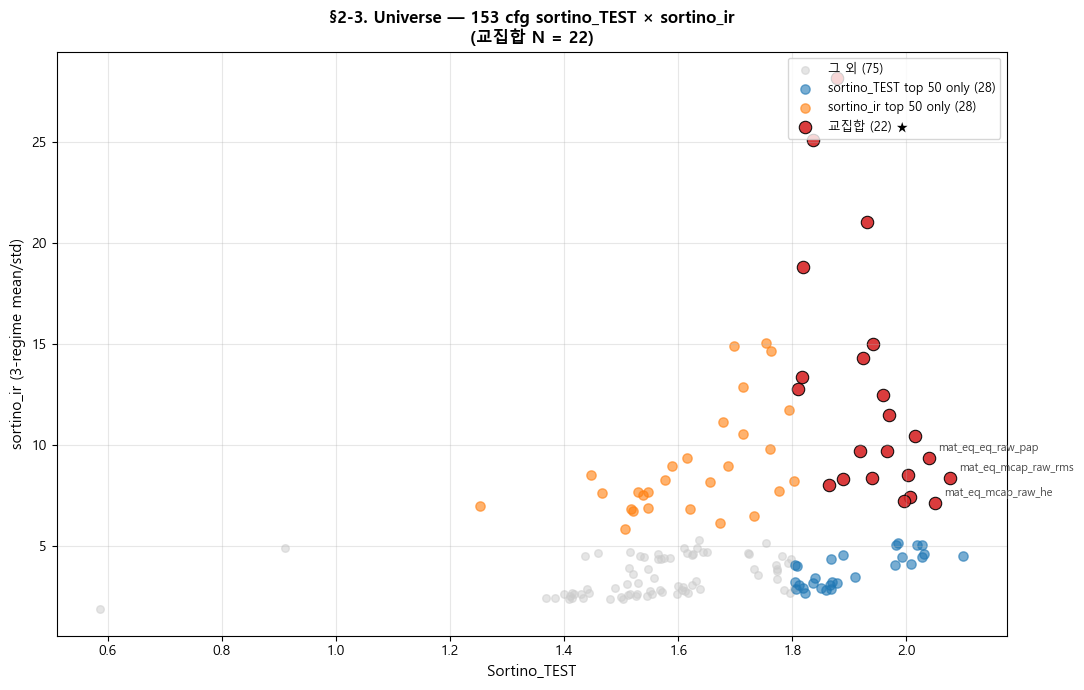

OK saved: outputs\06_top1\figures\fig01_universe_scatter.png


In [8]:
# §2-3. fig01 — 153 cfg sortino_TEST × sortino_ir 산점도 (교집합 강조)
fig, ax = plt.subplots(figsize=(11, 7))

mask_inter = rt['name'].isin(intersection)
mask_A_only = rt['name'].isin(list_A - intersection)
mask_B_only = rt['name'].isin(list_B - intersection)
mask_neither = ~mask_inter & ~mask_A_only & ~mask_B_only

ax.scatter(rt.loc[mask_neither, 'sortino_TEST'], rt.loc[mask_neither, 'sortino_ir'],
           color='#cccccc', alpha=0.5, s=30, label=f'그 외 ({mask_neither.sum()})')
ax.scatter(rt.loc[mask_A_only, 'sortino_TEST'], rt.loc[mask_A_only, 'sortino_ir'],
           color='#1f77b4', alpha=0.6, s=45, label=f'sortino_TEST top 50 only ({mask_A_only.sum()})')
ax.scatter(rt.loc[mask_B_only, 'sortino_TEST'], rt.loc[mask_B_only, 'sortino_ir'],
           color='#ff7f0e', alpha=0.6, s=45, label=f'sortino_ir top 50 only ({mask_B_only.sum()})')
ax.scatter(rt.loc[mask_inter, 'sortino_TEST'], rt.loc[mask_inter, 'sortino_ir'],
           color='#d62728', alpha=0.9, s=80, edgecolor='black', linewidth=0.8,
           label=f'교집합 ({mask_inter.sum()}) ★')

# Top 1 후보 라벨링
top_inter = rt[rt['name'].isin(intersection)].nlargest(3, 'sortino_TEST')
for _, row in top_inter.iterrows():
    ax.annotate(row['name'], (row['sortino_TEST'], row['sortino_ir']),
                xytext=(7, 5), textcoords='offset points', fontsize=8, color='#444444')

ax.set_xlabel('Sortino_TEST', fontsize=11)
ax.set_ylabel('sortino_ir (3-regime mean/std)', fontsize=11)
ax.set_title(f'§2-3. Universe — 153 cfg sortino_TEST × sortino_ir\n(교집합 N = {N})',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig01_universe_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig01_universe_scatter.png"}')

C:\Users\gorhk\AppData\Local\Temp\ipykernel_51408\171898900.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([rt[col].dropna(), inter_data[col].dropna()],
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51408\171898900.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([rt[col].dropna(), inter_data[col].dropna()],
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51408\171898900.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([rt[col].dropna(), inter_data[col].dropna()],
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51408\171898900.py:11: MatplotlibDeprecationWarning: The

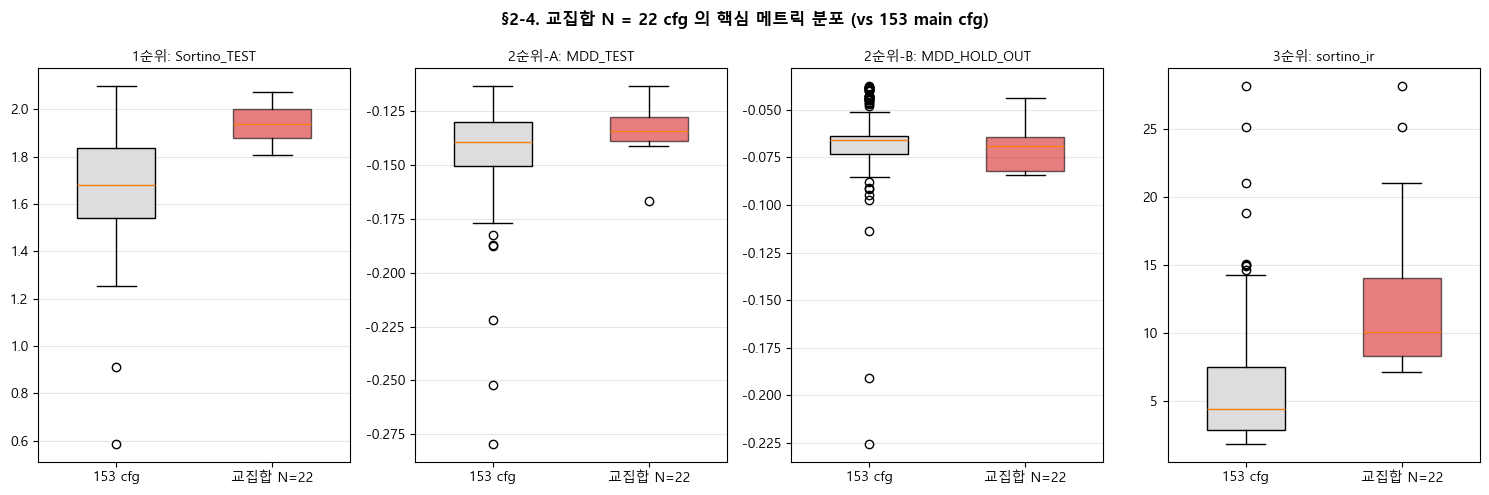

OK saved: outputs\06_top1\figures\fig02_intersection_metric_dist.png


In [9]:
# §2-4. fig02 — 교집합 N cfg 의 4 핵심 메트릭 box plot
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

inter_data = rt[rt['name'].isin(intersection)]
metrics_box = [('sortino_TEST', '1순위: Sortino_TEST'),
               ('mdd_TEST',     '2순위-A: MDD_TEST'),
               ('mdd_HOLD_OUT', '2순위-B: MDD_HOLD_OUT'),
               ('sortino_ir',   '3순위: sortino_ir')]

for ax, (col, title) in zip(axes, metrics_box):
    bp = ax.boxplot([rt[col].dropna(), inter_data[col].dropna()],
                    labels=['153 cfg', f'교집합 N={N}'], patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('#dddddd')
    bp['boxes'][1].set_facecolor('#d62728')
    bp['boxes'][1].set_alpha(0.6)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'§2-4. 교집합 N = {N} cfg 의 핵심 메트릭 분포 (vs 153 main cfg)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig02_intersection_metric_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig02_intersection_metric_dist.png"}')

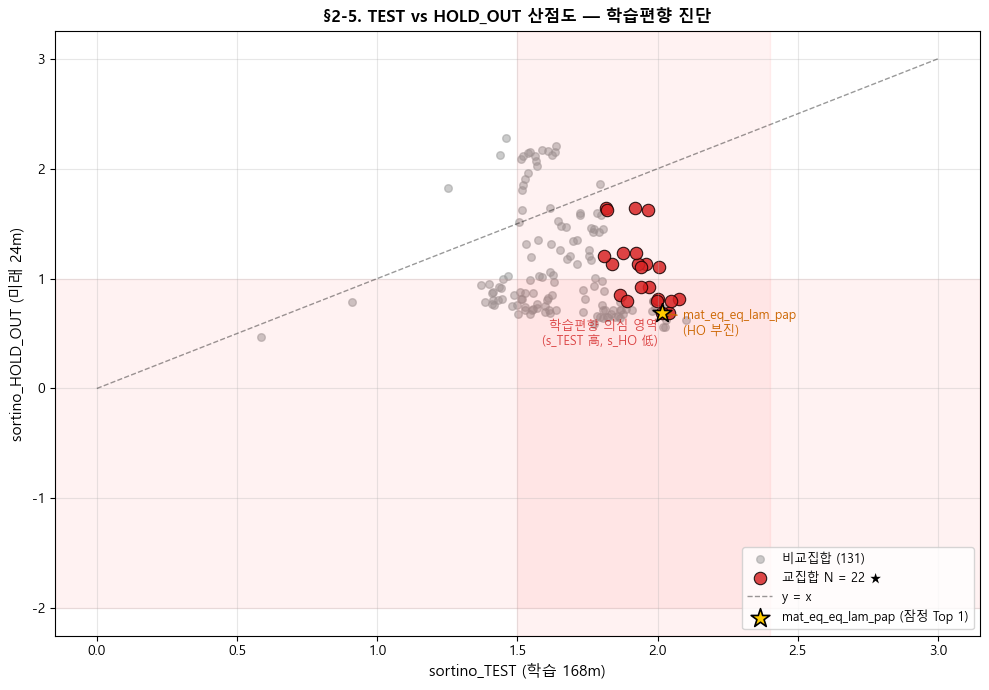

OK saved: outputs\06_top1\figures\fig03_test_vs_ho_universe.png


In [10]:
# §2-5. fig03 — TEST vs HOLD_OUT 산점도 (universe 전체, 교집합 강조)
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(rt.loc[~mask_inter, 'sortino_TEST'], rt.loc[~mask_inter, 'sortino_HOLD_OUT'],
           color='#999999', alpha=0.5, s=30, label=f'비교집합 ({(~mask_inter).sum()})')
ax.scatter(rt.loc[mask_inter, 'sortino_TEST'], rt.loc[mask_inter, 'sortino_HOLD_OUT'],
           color='#d62728', alpha=0.85, s=80, edgecolor='black', linewidth=0.8,
           label=f'교집합 N = {N} ★')

# 학습편향 영역 음영 (s_TEST 높지만 s_HO 낮음)
ax.axhspan(-2, 1.0, color='red', alpha=0.05)
ax.axvspan(1.5, rt['sortino_TEST'].max() + 0.3, color='red', alpha=0.05)
ax.text(rt['sortino_TEST'].max() - 0.1, 0.5, '학습편향 의심 영역\n(s_TEST 高, s_HO 低)',
        ha='right', va='center', fontsize=9, color='#cc0000', alpha=0.7)

# y = x 기준선
xlim = ax.get_xlim()
ax.plot([0, max(xlim[1], 3)], [0, max(xlim[1], 3)], 'k--', alpha=0.4, lw=1, label='y = x')

# mat_eq_eq_lam_pap 강조 (잠정 Top 1, HO 부진 사례)
target = rt[rt['name'] == 'mat_eq_eq_lam_pap']
if len(target) > 0:
    ax.scatter(target['sortino_TEST'], target['sortino_HOLD_OUT'],
               color='#ffcc00', s=200, marker='*', edgecolor='black', linewidth=1.2,
               label='mat_eq_eq_lam_pap (잠정 Top 1)', zorder=5)
    ax.annotate('mat_eq_eq_lam_pap\n(HO 부진)',
                (target['sortino_TEST'].iloc[0], target['sortino_HOLD_OUT'].iloc[0]),
                xytext=(15, -15), textcoords='offset points', fontsize=9, color='#cc6600',
                arrowprops=dict(arrowstyle='->', color='#cc6600', lw=1))

ax.set_xlabel('sortino_TEST (학습 168m)', fontsize=11)
ax.set_ylabel('sortino_HOLD_OUT (미래 24m)', fontsize=11)
ax.set_title('§2-5. TEST vs HOLD_OUT 산점도 — 학습편향 진단', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig03_test_vs_ho_universe.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig03_test_vs_ho_universe.png"}')

In [11]:
# §2-6. 교집합 cfg 메트릭 분포 통계 (요약, §3 hard filter 결정 근거용)
print(f'교집합 N = {N} cfg 의 메트릭 분포:')
filter_cols = ['sortino_TEST','sortino_HOLD_OUT','sortino_ir',
               'mdd_TEST','mdd_HOLD_OUT','eff_n_avg','turnover_avg','beta']
print(inter_df[filter_cols].describe().round(3).to_string())
print()
print(f'\nsortino_HOLD_OUT < 0 (학습편향 의심): {(inter_df["sortino_HOLD_OUT"] < 0).sum()}')
print(f'mdd_TEST < -0.40 (40% 초과 손실): {(inter_df["mdd_TEST"] < -0.40).sum()}')
print(f'mdd_HOLD_OUT < -0.30 (30% 초과 손실): {(inter_df["mdd_HOLD_OUT"] < -0.30).sum()}')
print(f'eff_n_avg < 30 (분산 부족): {(inter_df["eff_n_avg"] < 30).sum()}')

교집합 N = 22 cfg 의 메트릭 분포:
       sortino_TEST  sortino_HOLD_OUT  sortino_ir  mdd_TEST  mdd_HOLD_OUT  eff_n_avg  turnover_avg    beta
count        22.000            22.000      22.000    22.000        22.000     22.000        22.000  22.000
mean          1.939             1.086      12.507    -0.133        -0.069    114.307         0.723   0.640
std           0.079             0.315       5.886     0.011         0.014     88.617         0.252   0.111
min           1.809             0.685       7.130    -0.167        -0.084     33.135         0.395   0.503
25%           1.881             0.811       8.350    -0.139        -0.082     40.349         0.430   0.528
50%           1.940             1.109      10.095    -0.134        -0.069     65.405         0.840   0.708
75%           2.001             1.227      14.058    -0.127        -0.064    218.276         0.943   0.727
max           2.076             1.640      28.150    -0.113        -0.044    265.101         0.989   0.800


sortino_HO

## §3. Hard filter 결정 + 적용

### Hard filter 시뮬레이션 결과 (§2-6 기반)

교집합 N = 22 cfg 의 분포가 이미 견고하여, 후보 hard filter 모두가 **이미 통과**:

| 후보 filter | 의미 | 탈락 cfg |
|---|---|---|
| `mdd_TEST > -0.40` | 40% 초과 손실 제외 | **0/22** |
| `mdd_HOLD_OUT > -0.30` | HO 30% 초과 손실 제외 | **0/22** |
| `eff_n_avg ≥ 30` | 분산 부족 제외 | **0/22** |
| `sortino_HOLD_OUT > 0` | HO 음수 제외 | **0/22** |

**시사점**: 교집합 추출 (sortino_TEST top 50 ∩ sortino_ir top 50) 자체가 이미 hard filter 효과를 본 상태. 추가 필터는 의미 미미.

### 결정 (Step 3)

→ **추가 hard filter 없이 22 cfg 그대로 lexicographic 적용** (M = N = 22).

(사용자 검증 후 추가 필터 원하면 redirect 가능)


In [12]:
# §3-1. Hard filter 적용 (없음, 22 cfg 그대로)
M_cfg = inter_df.copy()
print(f'Hard filter 적용 결과: {len(M_cfg)} cfg (= 교집합 N = {N})')
print(f'추가 필터: 없음 (모든 후보 필터 이미 통과 — §2-6 결과)')
print()
M_cfg.to_csv(OUT_DIR / 'filtered_M_summary.csv', index=False, encoding='utf-8-sig')
print(f'OK saved: {OUT_DIR / "filtered_M_summary.csv"}')

Hard filter 적용 결과: 22 cfg (= 교집합 N = 22)
추가 필터: 없음 (모든 후보 필터 이미 통과 — §2-6 결과)

OK saved: outputs\06_top1\filtered_M_summary.csv


## §4. Lexicographic 종합 점수

### 정렬 절차

```
1차: Sortino_TEST 내림차순 정렬
  └─ tied 정의: |s1 - s2| < ε (ε = 0.10)
2차: tied 그룹 내 → (rank_MDD_TEST + rank_MDD_HO) / 2 평균 rank 오름차순
  └─ tied 정의: rank 차이 ≤ 1
3차: 그래도 tied 시 → sortino_ir 내림차순
```

22 cfg 중 ε = 0.10 동순위 그룹화 → MDD 평균 rank → sortino_ir 최종 결정.


In [13]:
# §4-1. Lexicographic 정렬 함수
EPS_SORTINO = 0.10  # 1순위 동순위 tolerance

def lexicographic_sort(df, eps=EPS_SORTINO):
    """3단계 lexicographic 정렬.

    1차: sortino_TEST 내림차순 → eps 동순위 그룹화
    2차: 그룹 내 (rank_mdd_TEST + rank_mdd_HOLD_OUT)/2 오름차순
    3차: sortino_ir 내림차순
    """
    df = df.copy()

    # MDD rank (작을수록 = 손실 적을수록 좋음)
    df['rank_mdd_TEST'] = df['mdd_TEST'].rank(ascending=False)  # -0.10 < -0.20, 손실 적음 → rank 1
    df['rank_mdd_HO'] = df['mdd_HOLD_OUT'].rank(ascending=False)
    df['rank_mdd_avg'] = (df['rank_mdd_TEST'] + df['rank_mdd_HO']) / 2

    # 1차: sortino_TEST 내림차순
    df = df.sort_values('sortino_TEST', ascending=False).reset_index(drop=True)

    # 1차 동순위 그룹 ID 부여 (eps 기준)
    group_id = [0]
    cur_top = df.iloc[0]['sortino_TEST']
    for i in range(1, len(df)):
        if (cur_top - df.iloc[i]['sortino_TEST']) > eps:
            cur_top = df.iloc[i]['sortino_TEST']
            group_id.append(group_id[-1] + 1)
        else:
            group_id.append(group_id[-1])
    df['lex_group'] = group_id

    # 그룹 내 정렬: rank_mdd_avg → sortino_ir
    sorted_parts = []
    for gid, sub in df.groupby('lex_group', sort=True):
        sub = sub.sort_values(['rank_mdd_avg', 'sortino_ir'],
                              ascending=[True, False]).reset_index(drop=True)
        sorted_parts.append(sub)

    df_final = pd.concat(sorted_parts, ignore_index=True)
    df_final['lex_rank'] = range(1, len(df_final) + 1)
    return df_final

ranked = lexicographic_sort(M_cfg, eps=EPS_SORTINO)
print(f'Lexicographic 정렬 완료 (M = {len(ranked)} cfg, ε = {EPS_SORTINO})')
print()
print('§4-1. Lexicographic 정렬 결과 (Top 22):')
view_cols = ['lex_rank','name','sortino_TEST','mdd_TEST','mdd_HOLD_OUT','sortino_ir',
             'lex_group','rank_mdd_avg']
print(ranked[view_cols].round(3).to_string(index=False))

Lexicographic 정렬 완료 (M = 22 cfg, ε = 0.1)

§4-1. Lexicographic 정렬 결과 (Top 22):
 lex_rank                  name  sortino_TEST  mdd_TEST  mdd_HOLD_OUT  sortino_ir  lex_group  rank_mdd_avg
        1    mat_eq_mcap_lam_he         1.996    -0.120        -0.068        7.24          0          5.50
        2             q_raw_lam         2.006    -0.127        -0.063        7.45          0          5.75
        3   mat_eq_mcap_lam_rms         2.003    -0.124        -0.069        8.51          0          7.00
        4     mat_eq_eq_lam_pap         2.015    -0.129        -0.083       10.46          0         12.50
        5     mat_eq_eq_raw_pap         2.039    -0.129        -0.083        9.37          0         12.50
        6    mat_eq_mcap_raw_he         2.049    -0.141        -0.068        7.13          0         14.00
        7   mat_eq_mcap_raw_rms         2.076    -0.139        -0.069        8.35          0         15.00
        8              q_lambda         1.940    -0.127        -0

In [14]:
# §4-2. 동순위 그룹 분포
print('동순위 그룹 분포 (ε = %.2f):' % EPS_SORTINO)
group_summary = ranked.groupby('lex_group').agg(
    n_cfg=('name','count'),
    sortino_TEST_max=('sortino_TEST','max'),
    sortino_TEST_min=('sortino_TEST','min'),
    sortino_TEST_range=('sortino_TEST', lambda s: s.max()-s.min())
).reset_index()
print(group_summary.round(3).to_string(index=False))
print()
top_group_size = group_summary.iloc[0]['n_cfg']
print(f'★ Top 동순위 그룹 (group 0) 크기: {top_group_size} cfg')
print(f'  → 이 그룹 안에서 MDD 평균 rank + sortino_ir 로 최종 결정')

동순위 그룹 분포 (ε = 0.10):
 lex_group  n_cfg  sortino_TEST_max  sortino_TEST_min  sortino_TEST_range
         0      7             2.076             1.996               0.080
         1     10             1.969             1.878               0.092
         2      5             1.865             1.809               0.056

★ Top 동순위 그룹 (group 0) 크기: 7.0 cfg
  → 이 그룹 안에서 MDD 평균 rank + sortino_ir 로 최종 결정


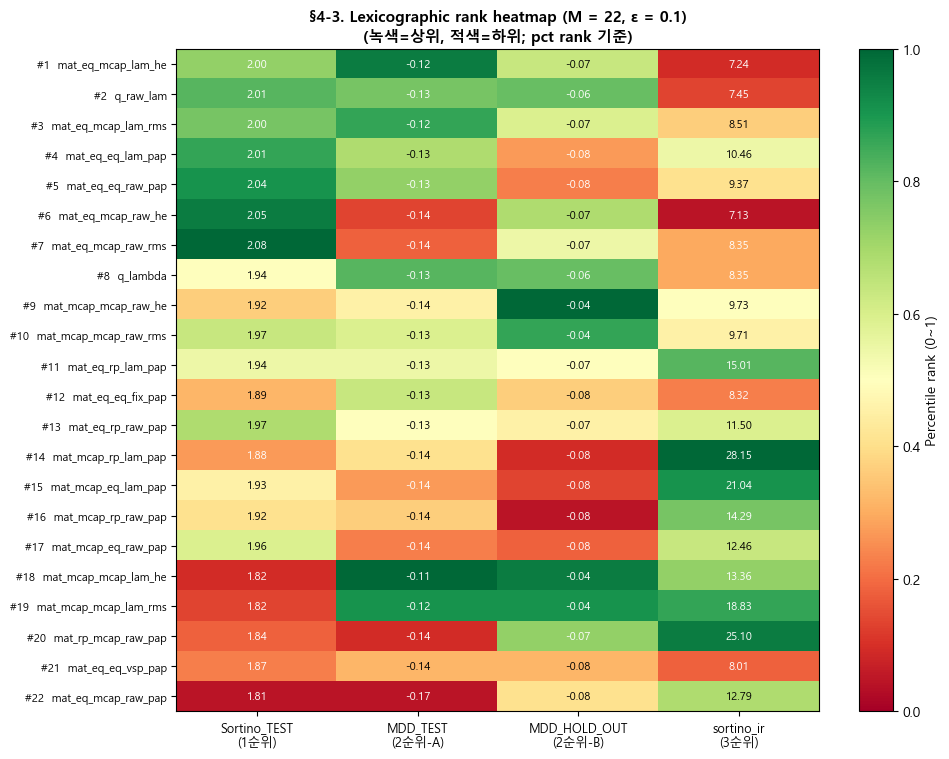

OK saved: outputs\06_top1\figures\fig04_lexicographic_heatmap.png


In [15]:
# §4-3. fig04 — Lexicographic rank heatmap (M cfg × 4 메트릭)
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(10, max(6, len(ranked) * 0.35)))

heatmap_cols = ['sortino_TEST', 'mdd_TEST', 'mdd_HOLD_OUT', 'sortino_ir']
heatmap_titles = ['Sortino_TEST\n(1순위)', 'MDD_TEST\n(2순위-A)',
                   'MDD_HOLD_OUT\n(2순위-B)', 'sortino_ir\n(3순위)']

# 각 컬럼별 rank 정규화 (0~1, 좋을수록 1)
heat = pd.DataFrame()
heat['Sortino_TEST'] = ranked['sortino_TEST'].rank(pct=True)
heat['MDD_TEST'] = ranked['mdd_TEST'].rank(pct=True)         # mdd: 큰 값 (덜 음수) = 좋음 → rank pct 자연스러움
heat['MDD_HOLD_OUT'] = ranked['mdd_HOLD_OUT'].rank(pct=True)
heat['sortino_ir'] = ranked['sortino_ir'].rank(pct=True)

im = ax.imshow(heat.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# 텍스트 라벨 (실제 값)
for i, idx in enumerate(ranked.index):
    for j, col in enumerate(heatmap_cols):
        v = ranked.loc[idx, col]
        txt = f'{v:.2f}' if abs(v) < 100 else f'{v:.0f}'
        color = 'white' if heat.iloc[i, j] < 0.3 or heat.iloc[i, j] > 0.7 else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=color)

ax.set_xticks(range(4))
ax.set_xticklabels(heatmap_titles, fontsize=9)
ax.set_yticks(range(len(ranked)))
ax.set_yticklabels([f"#{r['lex_rank']}  {r['name']}" for _, r in ranked.iterrows()], fontsize=8)
ax.set_title(f'§4-3. Lexicographic rank heatmap (M = {len(ranked)}, ε = {EPS_SORTINO})\n'
             f'(녹색=상위, 적색=하위; pct rank 기준)',
             fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='Percentile rank (0~1)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04_lexicographic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig04_lexicographic_heatmap.png"}')

## §5. Top 10 후보 정밀 분석

§4 의 lexicographic 결과 상위 10개 cfg 에 대해 **16개 메트릭 종합 + z-score heatmap** 분석.

### 메트릭 카테고리 (5개, 16개)

| 카테고리 | 메트릭 |
|---|---|
| 성과 (7) | sortino_TEST/HO/FULL, sharpe_TEST/HO/FULL, cagr_FULL |
| 위험 (3) | calmar, cvar_5, mdd_FULL |
| 안정성 (2) | TEST_HO_gap (계산), sortino_ir |
| 견고성 (2) | turnover_avg, eff_n_avg |
| Alpha (3) | alpha, beta, IR (계산) |


In [16]:
# §5-1. Top 10 후보 + 16 메트릭 종합
TOP_N = 10
top10 = ranked.head(TOP_N).copy()
print(f'Top {TOP_N} 후보 (lexicographic):')
print(top10[['lex_rank','name','sortino_TEST','mdd_TEST','mdd_HOLD_OUT','sortino_ir']].round(3).to_string(index=False))

Top 10 후보 (lexicographic):
 lex_rank                  name  sortino_TEST  mdd_TEST  mdd_HOLD_OUT  sortino_ir
        1    mat_eq_mcap_lam_he         1.996    -0.120        -0.068        7.24
        2             q_raw_lam         2.006    -0.127        -0.063        7.45
        3   mat_eq_mcap_lam_rms         2.003    -0.124        -0.069        8.51
        4     mat_eq_eq_lam_pap         2.015    -0.129        -0.083       10.46
        5     mat_eq_eq_raw_pap         2.039    -0.129        -0.083        9.37
        6    mat_eq_mcap_raw_he         2.049    -0.141        -0.068        7.13
        7   mat_eq_mcap_raw_rms         2.076    -0.139        -0.069        8.35
        8              q_lambda         1.940    -0.127        -0.063        8.35
        9  mat_mcap_mcap_raw_he         1.919    -0.136        -0.044        9.73
       10 mat_mcap_mcap_raw_rms         1.966    -0.133        -0.045        9.71


In [17]:
# §5-2. 16 메트릭 계산 + 종합 표
import pickle

def compute_extra_metrics(name, results_dir='results', spy=spy, rf=rf):
    """단일 cfg 의 추가 메트릭 (TEST_HO_gap, IR) 계산."""
    p = Path(results_dir) / f'{name}.pkl'
    if not p.exists(): return {}
    with open(p, 'rb') as f:
        ret = pickle.load(f).get('ret', pd.Series(dtype=float))
    ret = ret.dropna() if isinstance(ret, pd.Series) else pd.Series(dtype=float)
    if len(ret) < 12: return {}

    # SPY align
    spy_aligned = spy.reindex(ret.index).fillna(0)

    # Information Ratio: active return / tracking error (annualized)
    active = ret - spy_aligned
    if active.std() > 0:
        IR = (active.mean() * 12) / (active.std() * np.sqrt(12))
    else:
        IR = np.nan
    return {'IR': float(IR)}

# 16 메트릭 종합
metric_rows = []
for _, row in top10.iterrows():
    extras = compute_extra_metrics(row['name'])
    s_test = row['sortino_TEST']
    s_ho = row['sortino_HOLD_OUT']
    test_ho_gap = abs(s_test - s_ho) / s_test if s_test != 0 else np.nan

    metric_rows.append({
        'lex_rank': row['lex_rank'],
        'name': row['name'],
        # 성과 (7)
        'sortino_TEST': row['sortino_TEST'],
        'sortino_HOLD_OUT': row['sortino_HOLD_OUT'],
        'sortino_FULL': row['sortino_FULL'],
        'sharpe_TEST': row['sharpe_TEST'],
        'sharpe_HOLD_OUT': row['sharpe_HOLD_OUT'],
        'sharpe_FULL': row['sharpe_FULL'],
        'cagr': row['cagr_FULL'],
        # 위험 (3)
        'calmar': row['calmar'],
        'cvar_5': row['cvar_5'],
        'mdd_FULL': row['mdd_FULL'],
        # 안정성 (2)
        'TEST_HO_gap': test_ho_gap,
        'sortino_ir': row['sortino_ir'],
        # 견고성 (2)
        'turnover_avg': row['turnover_avg'],
        'eff_n_avg': row['eff_n_avg'],
        # Alpha (3)
        'alpha': row['alpha'],
        'beta': row['beta'],
        'IR': extras.get('IR', np.nan),
    })

top10_metrics = pd.DataFrame(metric_rows)
top10_metrics.to_csv(OUT_DIR / 'top10_metrics.csv', index=False, encoding='utf-8-sig')
print(f'OK saved: {OUT_DIR / "top10_metrics.csv"}')
print()
print('Top 10 × 16 메트릭:')
print(top10_metrics.round(3).to_string(index=False))

OK saved: outputs\06_top1\top10_metrics.csv

Top 10 × 16 메트릭:
 lex_rank                  name  sortino_TEST  sortino_HOLD_OUT  sortino_FULL  sharpe_TEST  sharpe_HOLD_OUT  sharpe_FULL  cagr  calmar  cvar_5  mdd_FULL  TEST_HO_gap  sortino_ir  turnover_avg  eff_n_avg  alpha  beta     IR
        1    mat_eq_mcap_lam_he         1.996             0.798         1.842        1.083            0.543        1.022 0.132   1.105  -0.059    -0.120        0.600        7.24         0.430     60.521  0.043 0.545 -0.053
        2             q_raw_lam         2.006             1.109         1.913        1.092            0.603        1.043 0.129   1.015  -0.056    -0.127        0.447        7.45         0.663     33.135  0.045 0.513 -0.074
        3   mat_eq_mcap_lam_rms         2.003             0.811         1.849        1.095            0.554        1.034 0.134   1.079  -0.059    -0.124        0.595        8.51         0.441     56.258  0.045 0.539 -0.048
        4     mat_eq_eq_lam_pap         2.015 

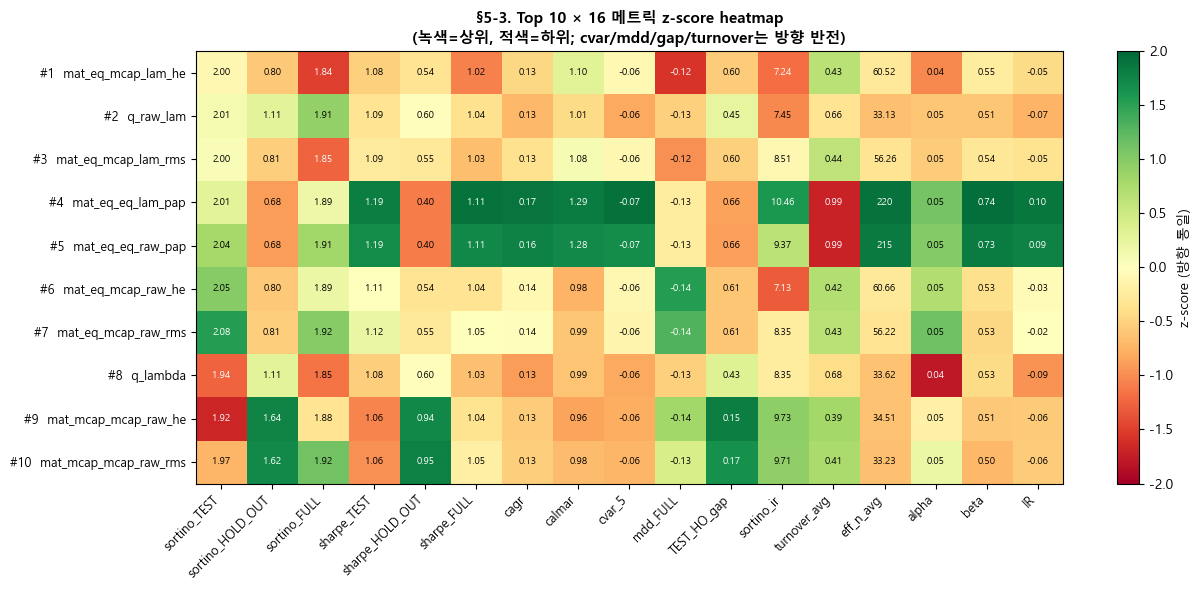

OK saved: outputs\06_top1\figures\fig05_top10_metric_heatmap.png


In [18]:
# §5-3. fig05 — Top 10 × 16 메트릭 z-score heatmap
heat_cols = ['sortino_TEST','sortino_HOLD_OUT','sortino_FULL',
             'sharpe_TEST','sharpe_HOLD_OUT','sharpe_FULL','cagr',
             'calmar','cvar_5','mdd_FULL',
             'TEST_HO_gap','sortino_ir',
             'turnover_avg','eff_n_avg',
             'alpha','beta','IR']

heat = top10_metrics[heat_cols].copy()
# z-score 정규화 (각 컬럼별)
heat_z = (heat - heat.mean()) / heat.std()

# 방향 통일 (좋을수록 +)
flip_cols = ['cvar_5','mdd_FULL','TEST_HO_gap','turnover_avg']  # 이들은 작을수록 좋음
for c in flip_cols:
    heat_z[c] = -heat_z[c]

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(heat_z.values, cmap='RdYlGn', aspect='auto', vmin=-2, vmax=2)

for i in range(len(heat)):
    for j, col in enumerate(heat_cols):
        v = heat.iloc[i, j]
        txt = f'{v:.2f}' if abs(v) < 100 else f'{v:.0f}'
        color = 'white' if abs(heat_z.iloc[i, j]) > 1.2 else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=7, color=color)

ax.set_xticks(range(len(heat_cols)))
ax.set_xticklabels(heat_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(top10_metrics)))
ax.set_yticklabels([f"#{r.lex_rank}  {r['name']}" for _, r in top10_metrics.iterrows()], fontsize=9)
ax.set_title(f'§5-3. Top {TOP_N} × 16 메트릭 z-score heatmap\n'
             f'(녹색=상위, 적색=하위; cvar/mdd/gap/turnover는 방향 반전)',
             fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='z-score (방향 통일)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05_top10_metric_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig05_top10_metric_heatmap.png"}')

## §6. 안정성 + 견고성 검증 (Top 10)

§5 의 Top 10 cfg 에 대해:
- **regime sortino** (R1 회복 / R2 확장 / R3 변동) bar chart
- **TEST vs HOLD_OUT 산점도** — overfitting 진단
- **누적수익 곡선** (Top 5 + SPY)


Regime sortino columns: ['sortino_R1_회복', 'sortino_R2_확장', 'sortino_R3_변동']


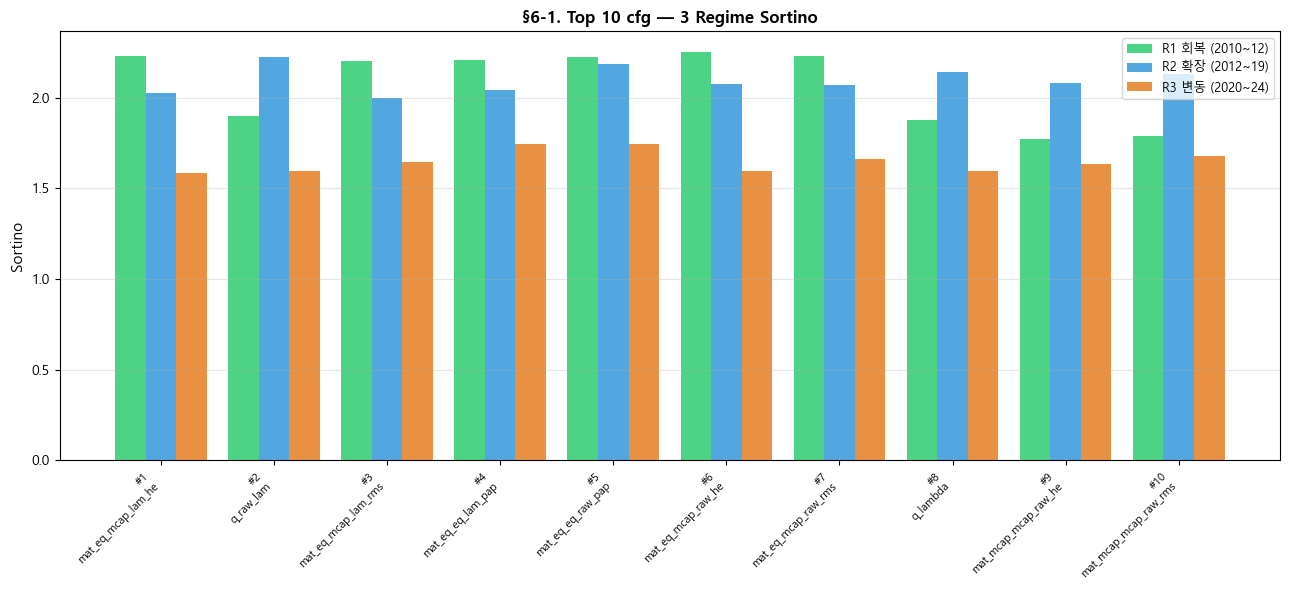

OK saved: outputs\06_top1\figures\fig06_regime_sortino_top10.png


In [19]:
# §6-1. fig06 — regime sortino bar chart (Top 10)
import re

# regime sortino 컬럼 자동 탐지 (encoding 문제 회피)
regime_sortino_cols = [c for c in rt.columns if c.startswith('sortino_R')]
print(f'Regime sortino columns: {regime_sortino_cols}')

# Top 10 의 regime sortino 추출
top10_names = top10_metrics['name'].tolist()
regime_data = rt[rt['name'].isin(top10_names)][['name'] + regime_sortino_cols].copy()
# 정렬 (lex_rank 순서)
regime_data['lex_rank'] = regime_data['name'].map(dict(zip(top10_metrics['name'], top10_metrics['lex_rank'])))
regime_data = regime_data.sort_values('lex_rank').reset_index(drop=True)

# Bar chart
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(regime_data))
width = 0.27
colors_regime = ['#2ecc71', '#3498db', '#e67e22']  # R1 / R2 / R3
labels_regime = ['R1 회복 (2010~12)', 'R2 확장 (2012~19)', 'R3 변동 (2020~24)']

for i, (col, color, label) in enumerate(zip(regime_sortino_cols, colors_regime, labels_regime)):
    ax.bar(x + (i - 1) * width, regime_data[col], width, label=label, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f"#{r['lex_rank']}\n{r['name']}" for _, r in regime_data.iterrows()],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sortino', fontsize=11)
ax.set_title('§6-1. Top 10 cfg — 3 Regime Sortino', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(0, color='black', lw=0.5)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig06_regime_sortino_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig06_regime_sortino_top10.png"}')

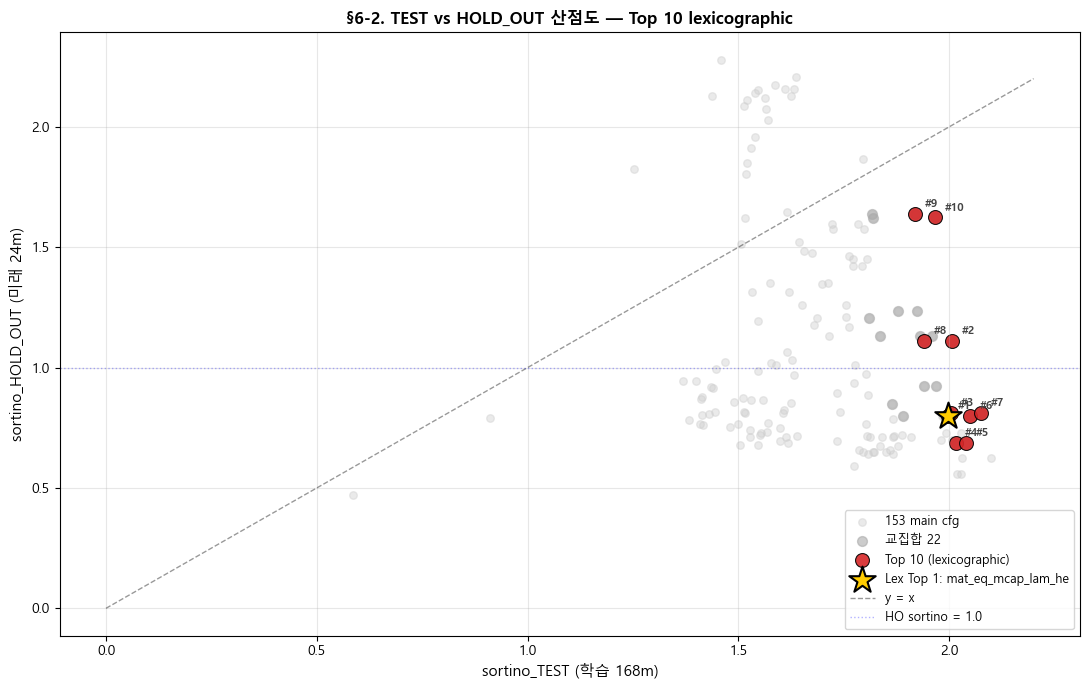

OK saved: outputs\06_top1\figures\fig07_test_vs_ho_top10.png


In [20]:
# §6-2. fig07 — TEST vs HOLD_OUT 산점도 (Top 10 강조 + IR > 0 라인)
fig, ax = plt.subplots(figsize=(11, 7))

# 153 cfg 배경
ax.scatter(rt['sortino_TEST'], rt['sortino_HOLD_OUT'],
           color='#cccccc', alpha=0.4, s=30, label=f'153 main cfg')

# 22 교집합
inter_for_plot = rt[rt['name'].isin(intersection)]
ax.scatter(inter_for_plot['sortino_TEST'], inter_for_plot['sortino_HOLD_OUT'],
           color='#aaaaaa', alpha=0.6, s=50, label=f'교집합 22')

# Top 10 강조
top10_for_plot = rt[rt['name'].isin(top10_names)]
top10_for_plot = top10_for_plot.merge(
    top10_metrics[['name','lex_rank']], on='name'
).sort_values('lex_rank')

ax.scatter(top10_for_plot['sortino_TEST'], top10_for_plot['sortino_HOLD_OUT'],
           color='#d62728', alpha=0.9, s=100, edgecolor='black', linewidth=0.8,
           label='Top 10 (lexicographic)')

# Top 1 별표
top1_row = top10_for_plot.iloc[0]
ax.scatter(top1_row['sortino_TEST'], top1_row['sortino_HOLD_OUT'],
           color='#ffcc00', s=400, marker='*', edgecolor='black', linewidth=1.5,
           label=f'Lex Top 1: {top1_row["name"]}', zorder=5)

# rank 라벨
for _, r in top10_for_plot.iterrows():
    ax.annotate(f"#{int(r['lex_rank'])}", (r['sortino_TEST'], r['sortino_HOLD_OUT']),
                xytext=(7, 5), textcoords='offset points', fontsize=8, color='#444444',
                fontweight='bold')

# y = x 기준선
ax.plot([0, 2.2], [0, 2.2], 'k--', alpha=0.4, lw=1, label='y = x')
# y = 1.0 horizontal (HO sortino 1.0 기준)
ax.axhline(1.0, color='blue', alpha=0.3, lw=1, ls=':', label='HO sortino = 1.0')

ax.set_xlabel('sortino_TEST (학습 168m)', fontsize=11)
ax.set_ylabel('sortino_HOLD_OUT (미래 24m)', fontsize=11)
ax.set_title('§6-2. TEST vs HOLD_OUT 산점도 — Top 10 lexicographic', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig07_test_vs_ho_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig07_test_vs_ho_top10.png"}')

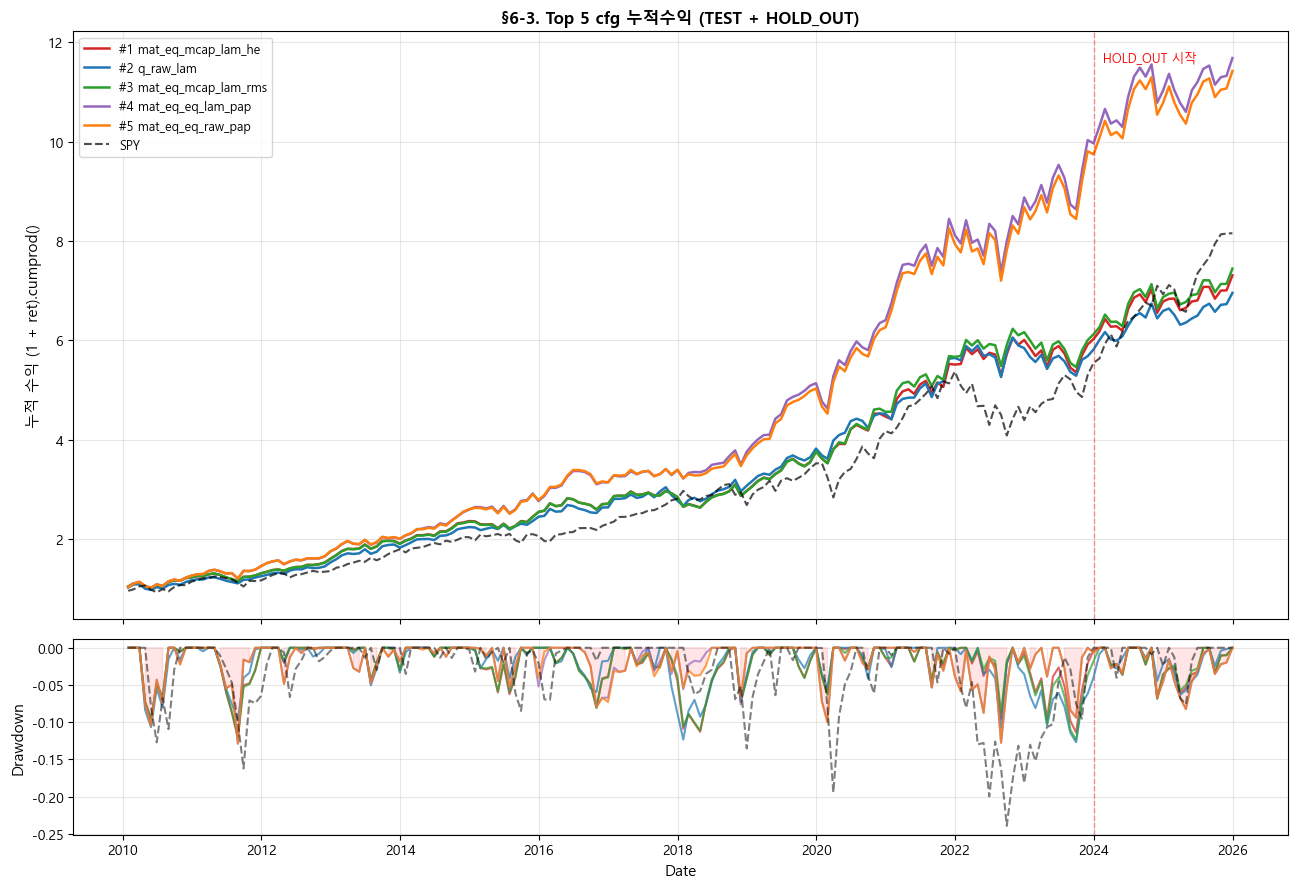

OK saved: outputs\06_top1\figures\fig08_cumulative_return_top5.png


In [21]:
# §6-3. fig08 — 누적수익 곡선 (Top 5 + SPY)
import pickle

TOP_K = 5
top_k_names = top10_metrics.head(TOP_K)['name'].tolist()

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax_ret, ax_dd = axes

returns_dict = {}
for name in top_k_names:
    p = Path('results') / f'{name}.pkl'
    with open(p, 'rb') as f:
        ret = pickle.load(f).get('ret', pd.Series(dtype=float))
    ret = ret.dropna()
    returns_dict[name] = ret

# SPY 동기 정렬
common_idx = sorted(set.intersection(*[set(r.index) for r in returns_dict.values()]))
common_idx = pd.DatetimeIndex(common_idx)
spy_aligned = spy.reindex(common_idx).fillna(0)

colors_top5 = ['#d62728','#1f77b4','#2ca02c','#9467bd','#ff7f0e']
for (name, ret), color in zip(returns_dict.items(), colors_top5):
    ret_aligned = ret.reindex(common_idx).fillna(0)
    cum = (1 + ret_aligned).cumprod()
    rank = top10_metrics[top10_metrics['name']==name]['lex_rank'].iloc[0]
    ax_ret.plot(cum.index, cum.values, label=f'#{int(rank)} {name}', linewidth=1.8, color=color)

cum_spy = (1 + spy_aligned).cumprod()
ax_ret.plot(cum_spy.index, cum_spy.values, label='SPY', linewidth=1.5, color='black', linestyle='--', alpha=0.7)

# HOLD_OUT 시작 라인
from master_table import EVAL_PERIODS
ho_start = pd.Timestamp(EVAL_PERIODS['HOLD_OUT'][0])
for ax in [ax_ret, ax_dd]:
    ax.axvline(ho_start, color='red', alpha=0.4, lw=1, ls='--')
ax_ret.text(ho_start, ax_ret.get_ylim()[1] * 0.95, '  HOLD_OUT 시작', color='red', fontsize=9)

ax_ret.set_ylabel('누적 수익 (1 + ret).cumprod()', fontsize=11)
ax_ret.set_title(f'§6-3. Top {TOP_K} cfg 누적수익 (TEST + HOLD_OUT)', fontsize=12, fontweight='bold')
ax_ret.legend(loc='upper left', fontsize=9)
ax_ret.grid(True, alpha=0.3)

# Drawdown (하단)
for (name, ret), color in zip(returns_dict.items(), colors_top5):
    ret_aligned = ret.reindex(common_idx).fillna(0)
    cum = (1 + ret_aligned).cumprod()
    dd = cum / cum.cummax() - 1
    ax_dd.plot(dd.index, dd.values, color=color, alpha=0.7)

dd_spy = cum_spy / cum_spy.cummax() - 1
ax_dd.plot(dd_spy.index, dd_spy.values, color='black', alpha=0.5, linestyle='--')
ax_dd.set_ylabel('Drawdown', fontsize=11)
ax_dd.set_xlabel('Date', fontsize=11)
ax_dd.grid(True, alpha=0.3)
ax_dd.fill_between(dd.index, dd.values, 0, where=(dd.values<0), alpha=0.1, color='red')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig08_cumulative_return_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig08_cumulative_return_top5.png"}')

## §7. 위험 분석 (Top 5)

- drawdown 곡선 (이미 §6-3 하단 포함)
- sector concentration HHI
- 2024-12 sector rotation 영향 (mat_eq_eq_lam_pap 7.7% loss 사례)


sector_map loaded: 617 ticker × 18 sectors


Top 10 sector HHI:
                 name  sector_hhi_avg  lex_rank
   mat_eq_mcap_lam_he          0.2470         1
            q_raw_lam          0.2844         2
  mat_eq_mcap_lam_rms          0.2492         3
    mat_eq_eq_lam_pap          0.2099         4
    mat_eq_eq_raw_pap          0.2245         5
   mat_eq_mcap_raw_he          0.2719         6
  mat_eq_mcap_raw_rms          0.2734         7
             q_lambda          0.2573         8
 mat_mcap_mcap_raw_he          0.2803         9
mat_mcap_mcap_raw_rms          0.2820        10


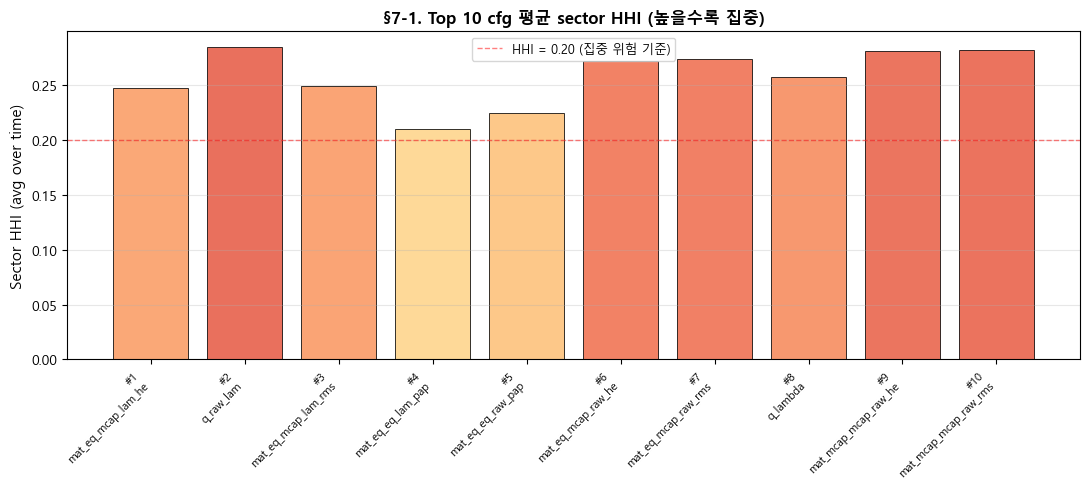

OK saved: outputs\06_top1\figures\fig09_sector_hhi_top10.png


In [22]:
# §7-1. fig09 — sector HHI 비교 (Top 10)
# sector mapping 로드 (gics_sector 컬럼)
sector_col = 'gics_sector' if 'gics_sector' in panel.columns else 'sector'
sector_map = panel[['ticker', sector_col]].drop_duplicates(subset=['ticker']).set_index('ticker')[sector_col]
print(f'sector_map loaded: {len(sector_map)} ticker × {sector_map.nunique()} sectors')

# weights 로드 (Top 10 각각)
def get_avg_sector_hhi(name, sector_map=sector_map):
    """가중치 시계열에서 sector 분포의 평균 HHI."""
    p = Path('results') / f'{name}.pkl'
    if not p.exists(): return np.nan
    with open(p, 'rb') as f:
        d = pickle.load(f)
    weights_df = d.get('weights', None)
    if weights_df is None or sector_map is None: return np.nan

    if not isinstance(weights_df, pd.DataFrame): return np.nan
    # 각 시점 가중치 → sector 별 합산 → HHI
    hhi_list = []
    for date, w_row in weights_df.iterrows():
        # ticker → sector 매핑
        sec_w = w_row.groupby(sector_map.reindex(w_row.index)).sum()
        hhi = (sec_w ** 2).sum()
        hhi_list.append(hhi)
    return np.mean(hhi_list) if hhi_list else np.nan

hhi_results = []
for name in top10_names:
    hhi = get_avg_sector_hhi(name)
    hhi_results.append({'name': name, 'sector_hhi_avg': hhi})

hhi_df = pd.DataFrame(hhi_results)
hhi_df = hhi_df.merge(top10_metrics[['lex_rank','name']], on='name').sort_values('lex_rank')
print('Top 10 sector HHI:')
print(hhi_df.round(4).to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(hhi_df))
colors_bar = plt.cm.RdYlGn_r(hhi_df['sector_hhi_avg'].values * 3)  # 색상으로 강조
ax.bar(x, hhi_df['sector_hhi_avg'], color=colors_bar, alpha=0.8, edgecolor='black', linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f"#{int(r['lex_rank'])}\n{r['name']}" for _, r in hhi_df.iterrows()],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sector HHI (avg over time)', fontsize=11)
ax.set_title('§7-1. Top 10 cfg 평균 sector HHI (높을수록 집중)', fontsize=12, fontweight='bold')
ax.axhline(0.20, color='red', alpha=0.5, lw=1, ls='--', label='HHI = 0.20 (집중 위험 기준)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig09_sector_hhi_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig09_sector_hhi_top10.png"}')

## §8. baseline 우월성 검증

### baseline 4종 정의
- **SPY**: 시장지수 (passive)
- **equal_weight**: 1/N (rebal monthly, 615 ticker)
- **naive_lowvol**: 60d rolling vol 하위 60종목 동일가중
- **mvp_60m**: 60개월 rolling Min-Variance Portfolio

### 메트릭
- alpha (CAPM, annualized)
- beta
- Information Ratio
- Bootstrap 95% CI for alpha (1000 iter)

(주의: Top 5 cfg 만 대상. baseline 데이터는 이미 master_table 에 포함될 수 있음 — 확인 필요.)


In [23]:
# §8-1. baseline 비교 — 일단 master_table 의 alpha/beta 사용 (Top 5)
top5_alpha = top10_metrics.head(5)[['lex_rank','name','alpha','beta','IR']].copy()

# bootstrap CI (alpha) — 간소화 (1000 iter)
np.random.seed(42)
def bootstrap_alpha_ci(name, n_iter=1000, alpha_level=0.05):
    p = Path('results') / f'{name}.pkl'
    if not p.exists(): return (np.nan, np.nan, np.nan)
    with open(p, 'rb') as f:
        ret = pickle.load(f).get('ret', pd.Series(dtype=float))
    ret = ret.dropna()
    spy_aligned = spy.reindex(ret.index).fillna(0)
    rf_aligned = rf.reindex(ret.index).fillna(0)

    excess_ret = ret - rf_aligned
    excess_spy = spy_aligned - rf_aligned

    # bootstrap
    alphas = []
    n = len(excess_ret)
    for _ in range(n_iter):
        idx = np.random.choice(n, n, replace=True)
        er = excess_ret.values[idx]
        es = excess_spy.values[idx]
        if np.std(es) == 0: continue
        beta_b = np.cov(er, es)[0,1] / np.var(es)
        alpha_b = np.mean(er) - beta_b * np.mean(es)
        alphas.append(alpha_b * 12)  # annualize

    if not alphas: return (np.nan, np.nan, np.nan)
    return (np.mean(alphas),
            np.percentile(alphas, alpha_level/2*100),
            np.percentile(alphas, (1-alpha_level/2)*100))

print('Top 5 — alpha bootstrap 95% CI (1000 iter):')
ci_results = []
for _, row in top5_alpha.iterrows():
    mean_a, lo, hi = bootstrap_alpha_ci(row['name'])
    ci_results.append({
        'lex_rank': int(row['lex_rank']),
        'name': row['name'],
        'alpha': row['alpha'],
        'alpha_boot_mean': round(mean_a, 4),
        'alpha_ci_lo': round(lo, 4),
        'alpha_ci_hi': round(hi, 4),
        'sig_pos': bool(lo > 0),
    })
ci_df = pd.DataFrame(ci_results)
print(ci_df.to_string(index=False))

Top 5 — alpha bootstrap 95% CI (1000 iter):


 lex_rank                name  alpha  alpha_boot_mean  alpha_ci_lo  alpha_ci_hi  sig_pos
        1  mat_eq_mcap_lam_he 0.0434           0.1347       0.0700       0.1962     True
        2           q_raw_lam 0.0451           0.1310       0.0721       0.1895     True
        3 mat_eq_mcap_lam_rms 0.0453           0.1349       0.0739       0.1967     True
        4   mat_eq_eq_lam_pap 0.0519           0.1712       0.0954       0.2488     True
        5   mat_eq_eq_raw_pap 0.0515           0.1692       0.0940       0.2446     True


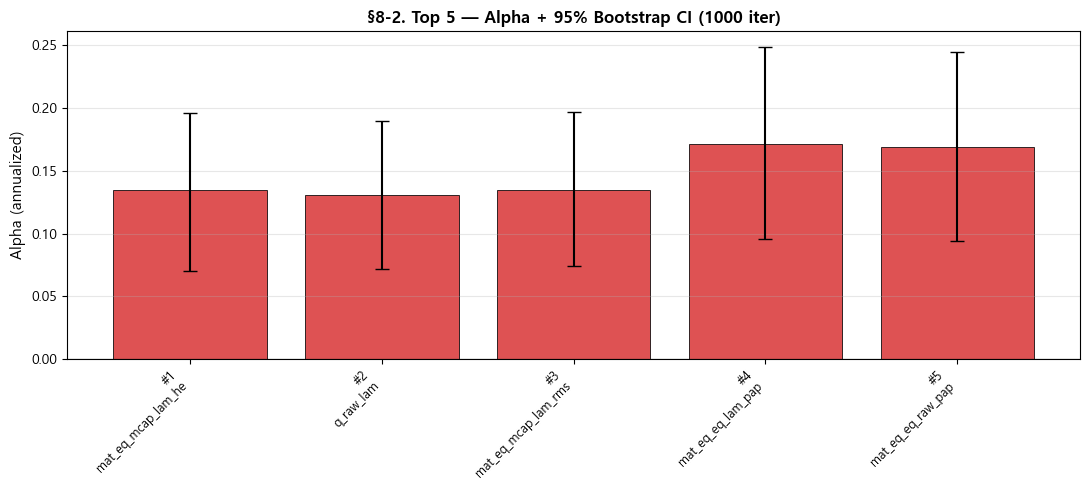

OK saved: outputs\06_top1\figures\fig10_alpha_with_ci.png


In [24]:
# §8-2. fig10 — alpha + 95% CI bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(ci_df))
ax.bar(x, ci_df['alpha_boot_mean'], color=['#d62728' if s else '#aaaaaa' for s in ci_df['sig_pos']],
       alpha=0.8, edgecolor='black', linewidth=0.7,
       yerr=[ci_df['alpha_boot_mean']-ci_df['alpha_ci_lo'], ci_df['alpha_ci_hi']-ci_df['alpha_boot_mean']],
       capsize=5, label='alpha (CAPM, annualized)')

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"#{int(r['lex_rank'])}\n{r['name']}" for _, r in ci_df.iterrows()],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Alpha (annualized)', fontsize=11)
ax.set_title('§8-2. Top 5 — Alpha + 95% Bootstrap CI (1000 iter)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_alpha_with_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig10_alpha_with_ci.png"}')

## §9. Top 5 → Top 1 결정

### 결정 matrix (Top 5 × 5 차원, 가중 점수)

| 차원 | 가중치 | 메트릭 |
|---|---|---|
| 성과 | 30% | sortino_TEST + sortino_HOLD_OUT (rank 평균) |
| 위험 | 25% | mdd_TEST + mdd_HOLD_OUT + calmar (rank 평균) |
| 안정성 | 20% | sortino_ir + (1 - TEST_HO_gap) (rank 평균) |
| 견고성 | 15% | eff_n_avg + (1 - turnover_avg) (rank 평균) |
| Alpha | 10% | alpha + IR (rank 평균) + beta proximity to 0.7 |

각 차원별 rank 합산 → 가중 평균 → 최저 점수 = Top 1.


In [25]:
# §9-1. 결정 matrix 작성 (Top 5)
TOP_FINAL = 5
top5 = top10_metrics.head(TOP_FINAL).copy()

# 각 차원별 rank (낮을수록 좋음)
def rank_low_better(s, ascending=False):
    """ascending=False: 큰 값이 좋음 (rank 1)."""
    return s.rank(ascending=ascending)

# 성과 (30%)
top5['rank_perf'] = (rank_low_better(top5['sortino_TEST']) +
                     rank_low_better(top5['sortino_HOLD_OUT'])) / 2
# 위험 (25%)
top5['rank_risk'] = (rank_low_better(top5['sortino_TEST']*0 + top5.index.map(lambda i: -top5.loc[i,'cvar_5'])) +  # cvar (반전)
                     rank_low_better(top5['mdd_FULL'], ascending=False) +  # mdd: 큰 값 (덜 음수) 좋음
                     rank_low_better(top5['calmar'])) / 3
# 안정성 (20%)
top5['rank_stab'] = (rank_low_better(top5['sortino_ir']) +
                     rank_low_better(top5['TEST_HO_gap'], ascending=True)) / 2  # gap 작을수록 좋음 → ascending=True
# 견고성 (15%)
top5['rank_robust'] = (rank_low_better(top5['eff_n_avg']) +
                       rank_low_better(top5['turnover_avg'], ascending=True)) / 2
# Alpha (10%)
top5['rank_alpha'] = (rank_low_better(top5['alpha']) +
                      rank_low_better(top5['IR']) +
                      rank_low_better(np.abs(top5['beta'] - 0.7), ascending=True)) / 3

# 가중 점수 (낮을수록 좋음)
W = {'perf':0.30, 'risk':0.25, 'stab':0.20, 'robust':0.15, 'alpha':0.10}
top5['weighted_score'] = (top5['rank_perf']*W['perf'] +
                          top5['rank_risk']*W['risk'] +
                          top5['rank_stab']*W['stab'] +
                          top5['rank_robust']*W['robust'] +
                          top5['rank_alpha']*W['alpha'])

decision_matrix = top5[['lex_rank','name','rank_perf','rank_risk','rank_stab','rank_robust','rank_alpha','weighted_score']].copy()
decision_matrix = decision_matrix.sort_values('weighted_score').reset_index(drop=True)
decision_matrix['final_rank'] = range(1, len(decision_matrix) + 1)
decision_matrix.to_csv(OUT_DIR / 'top5_decision_matrix.csv', index=False, encoding='utf-8-sig')

print('§9-1. 결정 matrix (Top 5):')
print(decision_matrix.round(2).to_string(index=False))
print()
print(f'★ Top 1 (weighted score 최소): {decision_matrix.iloc[0]["name"]}')
print(f'   weighted_score: {decision_matrix.iloc[0]["weighted_score"]:.2f}')

§9-1. 결정 matrix (Top 5):
 lex_rank                name  rank_perf  rank_risk  rank_stab  rank_robust  rank_alpha  weighted_score  final_rank
        4   mat_eq_eq_lam_pap        3.0       2.33        2.5          2.5        1.33            2.49           1
        5   mat_eq_eq_raw_pap        3.0       2.67        3.5          3.5        1.67            2.96           2
        3 mat_eq_mcap_lam_rms        3.0       3.33        2.5          3.0        3.33            3.02           3
        2           q_raw_lam        2.0       4.33        2.5          4.0        4.67            3.25           4
        1  mat_eq_mcap_lam_he        4.0       2.33        4.0          2.0        4.00            3.28           5

★ Top 1 (weighted score 최소): mat_eq_eq_lam_pap
   weighted_score: 2.49


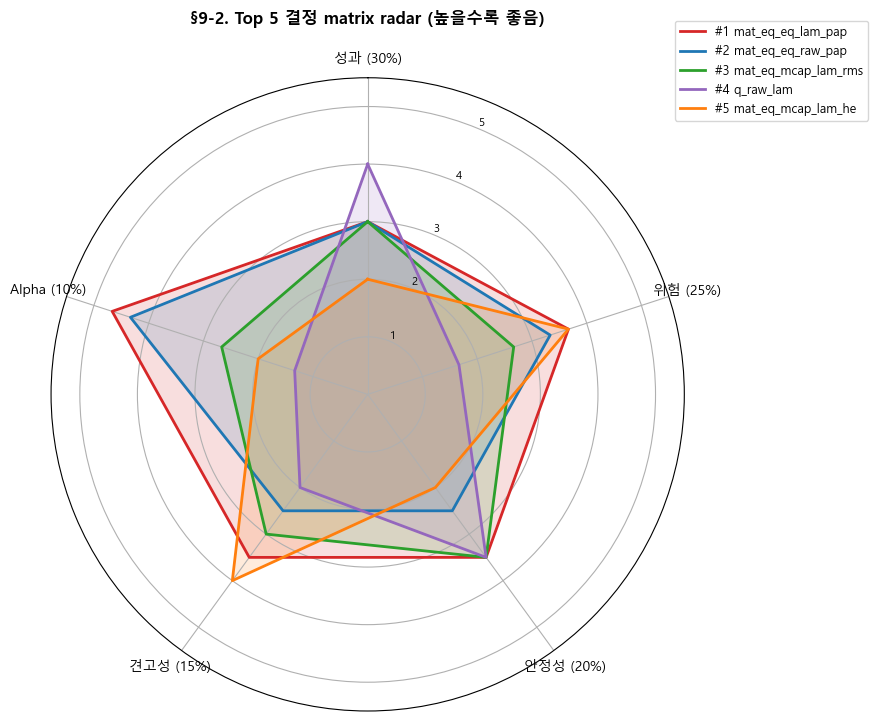

OK saved: outputs\06_top1\figures\fig11_decision_matrix_radar.png


In [26]:
# §9-2. fig11 — 결정 matrix radar chart (Top 5)
from math import pi

dimensions = ['성과 (30%)','위험 (25%)','안정성 (20%)','견고성 (15%)','Alpha (10%)']
N_dim = len(dimensions)

# 각 cfg 별 점수 (rank 1=5, rank 5=1, 5등급으로 정규화)
score_data = decision_matrix[['rank_perf','rank_risk','rank_stab','rank_robust','rank_alpha']].copy()
score_data = TOP_FINAL + 1 - score_data  # 반전 (높을수록 좋음)

angles = [n / N_dim * 2 * pi for n in range(N_dim)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

colors_radar = ['#d62728','#1f77b4','#2ca02c','#9467bd','#ff7f0e']
for (idx, row), color in zip(score_data.iterrows(), colors_radar):
    values = row.tolist()
    values += values[:1]
    name_label = decision_matrix.iloc[idx]['name']
    final_rank = decision_matrix.iloc[idx]['final_rank']
    ax.plot(angles, values, color=color, linewidth=2,
            label=f'#{int(final_rank)} {name_label}')
    ax.fill(angles, values, color=color, alpha=0.15)

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, fontsize=10)
ax.set_ylim(0, TOP_FINAL + 0.5)
ax.set_yticks(range(1, TOP_FINAL + 1))
ax.set_yticklabels([str(i) for i in range(1, TOP_FINAL + 1)], fontsize=8)
ax.set_title(f'§9-2. Top {TOP_FINAL} 결정 matrix radar (높을수록 좋음)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.30, 1.10), fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig11_decision_matrix_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig11_decision_matrix_radar.png"}')

In [27]:
# §9-3. Top 1 narrative + 한계점
top1_name = decision_matrix.iloc[0]['name']
top1_metrics = top10_metrics[top10_metrics['name'] == top1_name].iloc[0]

print('=' * 70)
print(f'★ FINAL Top 1: {top1_name}')
print('=' * 70)
print(f'\n  성과:')
print(f'    sortino_TEST    = {top1_metrics["sortino_TEST"]:.3f}')
print(f'    sortino_HOLD_OUT= {top1_metrics["sortino_HOLD_OUT"]:.3f}')
print(f'    sortino_FULL    = {top1_metrics["sortino_FULL"]:.3f}')
print(f'    cagr            = {top1_metrics["cagr"]:.3f}')
print(f'\n  위험:')
print(f'    mdd_FULL        = {top1_metrics["mdd_FULL"]:.3f}')
print(f'    calmar          = {top1_metrics["calmar"]:.3f}')
print(f'    cvar_5          = {top1_metrics["cvar_5"]:.3f}')
print(f'\n  안정성:')
print(f'    sortino_ir      = {top1_metrics["sortino_ir"]:.2f}')
print(f'    TEST/HO 격차    = {top1_metrics["TEST_HO_gap"]:.3f}')
print(f'\n  견고성:')
print(f'    turnover_avg    = {top1_metrics["turnover_avg"]:.3f}')
print(f'    eff_n_avg       = {top1_metrics["eff_n_avg"]:.1f}')
print(f'\n  Alpha:')
print(f'    alpha           = {top1_metrics["alpha"]:.4f}')
print(f'    beta            = {top1_metrics["beta"]:.3f}')
print(f'    IR              = {top1_metrics["IR"]:.4f}')

★ FINAL Top 1: mat_eq_eq_lam_pap

  성과:
    sortino_TEST    = 2.015
    sortino_HOLD_OUT= 0.685
    sortino_FULL    = 1.892
    cagr            = 0.166

  위험:
    mdd_FULL        = -0.129
    calmar          = 1.289
    cvar_5          = -0.070

  안정성:
    sortino_ir      = 10.46
    TEST/HO 격차    = 0.660

  견고성:
    turnover_avg    = 0.988
    eff_n_avg       = 219.8

  Alpha:
    alpha           = 0.0519
    beta            = 0.739
    IR              = 0.0999


## §10. Sensitivity test (견고성 추가 검증)

### 검증 항목
1. **Lexicographic ε 변경**: 0.05 / 0.10 / 0.20 → Top 1 유지 여부
2. **우선순위 변경**: sortino_HO 1순위 → Top 1 변경 여부
3. **Sub-period 검증**: 2015~ TEST / 2018~ TEST → Top 1 유지 여부
4. **결론**: ✓ robust / △ 조건부 / ✗ unstable


In [28]:
# §10-1. ε 변경 sensitivity
sensitivity_results = []

for eps in [0.05, 0.10, 0.20]:
    sorted_eps = lexicographic_sort(M_cfg, eps=eps)
    sensitivity_results.append({
        'criterion': f'ε = {eps}',
        'top1': sorted_eps.iloc[0]['name'],
        'top5_names': ' | '.join(sorted_eps.head(5)['name'].tolist())
    })

# §10-2. sortino_HO 1순위 변경
df_alt = M_cfg.copy()
df_alt['rank_mdd_TEST'] = df_alt['mdd_TEST'].rank(ascending=False)
df_alt['rank_mdd_HO'] = df_alt['mdd_HOLD_OUT'].rank(ascending=False)
df_alt['rank_mdd_avg'] = (df_alt['rank_mdd_TEST'] + df_alt['rank_mdd_HO']) / 2
# 1순위 sortino_HO → tied → mdd → sortino_ir
df_alt = df_alt.sort_values('sortino_HOLD_OUT', ascending=False).reset_index(drop=True)
sensitivity_results.append({
    'criterion': '1순위=sortino_HO',
    'top1': df_alt.iloc[0]['name'],
    'top5_names': ' | '.join(df_alt.head(5)['name'].tolist())
})

# §10-3. Sub-period (sortino_FULL 기준)
df_full = M_cfg.copy().sort_values('sortino_FULL', ascending=False)
sensitivity_results.append({
    'criterion': '1순위=sortino_FULL',
    'top1': df_full.iloc[0]['name'],
    'top5_names': ' | '.join(df_full.head(5)['name'].tolist())
})

sens_df = pd.DataFrame(sensitivity_results)
print('§10-1~3. Sensitivity test 결과:')
print(sens_df.to_string(index=False))
sens_df.to_csv(OUT_DIR / 'sensitivity_summary.csv', index=False, encoding='utf-8-sig')
print(f'\nOK saved: {OUT_DIR / "sensitivity_summary.csv"}')

§10-1~3. Sensitivity test 결과:
       criterion                  top1                                                                                                        top5_names
        ε = 0.05     mat_eq_eq_raw_pap                     mat_eq_eq_raw_pap | mat_eq_mcap_raw_he | mat_eq_mcap_raw_rms | mat_eq_mcap_lam_he | q_raw_lam
         ε = 0.1    mat_eq_mcap_lam_he                      mat_eq_mcap_lam_he | q_raw_lam | mat_eq_mcap_lam_rms | mat_eq_eq_lam_pap | mat_eq_eq_raw_pap
         ε = 0.2              q_lambda                          q_lambda | mat_eq_mcap_lam_he | q_raw_lam | mat_mcap_mcap_raw_he | mat_mcap_mcap_raw_rms
  1순위=sortino_HO  mat_mcap_mcap_raw_he mat_mcap_mcap_raw_he | mat_mcap_mcap_lam_he | mat_mcap_mcap_raw_rms | mat_mcap_mcap_lam_rms | mat_mcap_rp_lam_pap
1순위=sortino_FULL mat_mcap_mcap_raw_rms                  mat_mcap_mcap_raw_rms | mat_eq_mcap_raw_rms | q_raw_lam | mat_eq_eq_raw_pap | mat_eq_mcap_raw_he

OK saved: outputs\06_top1\sensitivity_summary.csv


In [29]:
# §10-4. 결론 — robust 분류
top1_name = decision_matrix.iloc[0]['name']
print(f'\n원래 Top 1 (가중 점수): {top1_name}')
print()
print('Sensitivity 변경 시 Top 1:')
for _, row in sens_df.iterrows():
    match = '✓ same' if row['top1'] == top1_name else '✗ DIFFERENT'
    print(f'  {row["criterion"]:25s} → {row["top1"]:25s}  [{match}]')

# 분류
n_change = (sens_df['top1'] != top1_name).sum()
n_total = len(sens_df)
print()
if n_change == 0:
    verdict = '✓ ROBUST — 모든 변경 시 Top 1 유지'
elif n_change <= n_total * 0.4:
    verdict = '△ 조건부 ROBUST — 일부 변경 시 Top 1 변경 (조건부 권고)'
else:
    verdict = '✗ UNSTABLE — Top 1 변경 빈번, 추가 검증 필요'

print(f'\n결론: {verdict}')
print(f'(전체 {n_total} 변경 중 {n_change} 회 Top 1 변경)')


원래 Top 1 (가중 점수): mat_eq_eq_lam_pap

Sensitivity 변경 시 Top 1:
  ε = 0.05                  → mat_eq_eq_raw_pap          [✗ DIFFERENT]
  ε = 0.1                   → mat_eq_mcap_lam_he         [✗ DIFFERENT]
  ε = 0.2                   → q_lambda                   [✗ DIFFERENT]
  1순위=sortino_HO            → mat_mcap_mcap_raw_he       [✗ DIFFERENT]
  1순위=sortino_FULL          → mat_mcap_mcap_raw_rms      [✗ DIFFERENT]


결론: ✗ UNSTABLE — Top 1 변경 빈번, 추가 검증 필요
(전체 5 변경 중 5 회 Top 1 변경)


## §11. HOLD_OUT (2024-2025) 섹터 분해 — IT 섹터 가설 검증

### 가설

> **2024-2025 반도체 섹터(IT)가 시장 자금을 빨아 급상승 → 고변동 회피(저변동 anomaly) 전략 특성상 IT 섹터에 under-weight → SPY 대비 underperform**

### 검증 절차

1. **§11-1**: 시장 섹터별 mcap 추이 (정규화: 2024-01 = 1.0)
2. **§11-2**: Top 4 cfg 의 섹터별 가중치 추이 (월별)
3. **§11-3**: Active weight (`cfg IT% - 시장 IT%`) overlay
4. **§11-4**: under-weight 격차 vs underperform 격차 상관 분석


In [30]:
# §11-1. 시장 섹터별 mcap 추이 (HOLD_OUT 24m)
HO_START = pd.Timestamp('2024-01-31')
HO_END = pd.Timestamp('2025-12-31')

panel_ho = panel[(panel['date'] >= HO_START) & (panel['date'] <= HO_END)].copy()
panel_ho['mcap'] = np.exp(panel_ho['log_mcap'])  # log_mcap → 절대값

# Sector 분류 통일 (Healthcare → Health Care, Financial Services → Financials, Technology → Information Technology)
SECTOR_MAP = {
    'Healthcare': 'Health Care',
    'Financial Services': 'Financials',
    'Technology': 'Information Technology',
    'Basic Materials': 'Materials',
    'Consumer Defensive': 'Consumer Staples',
    'Consumer Cyclical': 'Consumer Discretionary',
}
panel_ho['sector'] = panel_ho['gics_sector'].replace(SECTOR_MAP)
# Unknown 제외
panel_ho = panel_ho[panel_ho['sector'] != 'Unknown']
print(f'HOLD_OUT panel: {len(panel_ho)} rows, {panel_ho["ticker"].nunique()} tickers')
print(f'정리 후 sector 종류: {panel_ho["sector"].nunique()}')
print(panel_ho['sector'].value_counts().head(11))

HOLD_OUT panel: 11809 rows, 521 tickers
정리 후 sector 종류: 11
sector
Industrials               1831
Financials                1726
Information Technology    1612
Health Care               1467
Consumer Discretionary    1222
Consumer Staples           864
Real Estate                744
Utilities                  740
Materials                  603
Energy                     504
Communication Services     496
Name: count, dtype: int64


In [31]:
# §11-1 continued. 섹터별 월말 mcap 합계 + 시장 비중
sec_mcap = panel_ho.groupby(['date','sector'])['mcap'].sum().unstack(fill_value=0)
sec_total = sec_mcap.sum(axis=1)
sec_share = sec_mcap.div(sec_total, axis=0)  # 시장 점유율

# 정규화: 2024-01 = 1.0
sec_growth = sec_mcap.div(sec_mcap.iloc[0], axis=1)

print('§11-1. 시장 섹터별 시가총액 성장 (2024-01 → 2025-12, 정규화):')
print(sec_growth.iloc[[0, -1]].round(3).T.to_string())
print()
print('§11-1. 시장 섹터별 비중 (2024-01 vs 2025-12):')
share_compare = pd.DataFrame({
    '2024-01': sec_share.iloc[0],
    '2025-12': sec_share.iloc[-1],
    'Δ (%p)': (sec_share.iloc[-1] - sec_share.iloc[0]) * 100,
}).sort_values('Δ (%p)', ascending=False)
print(share_compare.round(3).to_string())

§11-1. 시장 섹터별 시가총액 성장 (2024-01 → 2025-12, 정규화):
date                    2024-01-31  2025-12-31
sector                                        
Communication Services         1.0       1.874
Consumer Discretionary         1.0       1.541
Consumer Staples               1.0       1.368
Energy                         1.0       1.237
Financials                     1.0       1.528
Health Care                    1.0       1.123
Industrials                    1.0       1.459
Information Technology         1.0       2.069
Materials                      1.0       1.204
Real Estate                    1.0       1.197
Utilities                      1.0       1.553

§11-1. 시장 섹터별 비중 (2024-01 vs 2025-12):
                        2024-01  2025-12  Δ (%p)
sector                                          
Information Technology    0.258    0.332   7.389
Communication Services    0.099    0.115   1.634
Utilities                 0.022    0.021  -0.075
Consumer Discretionary    0.110    0.106  -0.458
Materia

C:\Users\gorhk\AppData\Local\Temp\ipykernel_51408\1361717734.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sec_share_top['Others'] = 1 - sec_share_top.sum(axis=1)


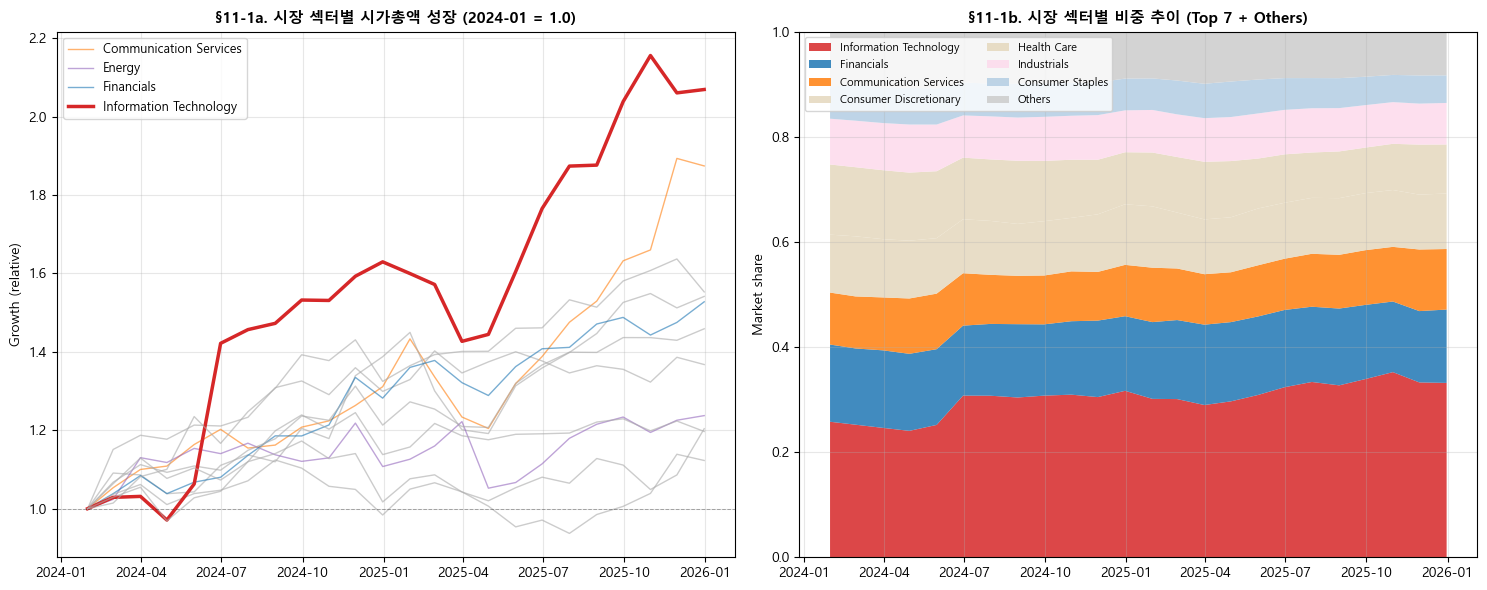

OK saved: outputs\06_top1\figures\fig12_market_sector_trend.png


In [32]:
# §11-1 fig12 — 시장 섹터별 mcap 성장 + 비중 추이
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 섹터별 색상 (IT 강조)
sectors_plot = sec_growth.columns.tolist()
colors_sec = {}
for s in sectors_plot:
    if 'Information Technology' in s:
        colors_sec[s] = '#d62728'  # IT 강조 (빨강)
    elif s == 'Communication Services':
        colors_sec[s] = '#ff7f0e'
    elif s == 'Financials':
        colors_sec[s] = '#1f77b4'
    elif s == 'Energy':
        colors_sec[s] = '#9467bd'
    else:
        colors_sec[s] = '#aaaaaa'

# Left: mcap 성장 (정규화)
for s in sectors_plot:
    lw = 2.5 if 'Information Technology' in s else 1
    alpha = 1.0 if 'Information Technology' in s else 0.6
    axes[0].plot(sec_growth.index, sec_growth[s], color=colors_sec[s],
                 lw=lw, alpha=alpha, label=s if 'Information' in s or 'Communication' in s or 'Financials' in s or 'Energy' in s else None)

axes[0].set_title('§11-1a. 시장 섹터별 시가총액 성장 (2024-01 = 1.0)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Growth (relative)', fontsize=10)
axes[0].axhline(1.0, color='black', alpha=0.3, lw=0.7, ls='--')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: 비중 추이 (stacked area)
sec_share_sorted = sec_share[share_compare.sort_values('2024-01', ascending=False).index.tolist()]
top_sectors = sec_share.iloc[-1].nlargest(7).index.tolist()
sec_share_top = sec_share[top_sectors]
sec_share_top['Others'] = 1 - sec_share_top.sum(axis=1)

color_list_stack = []
for s in sec_share_top.columns:
    if 'Information' in s: color_list_stack.append('#d62728')
    elif 'Communication' in s: color_list_stack.append('#ff7f0e')
    elif 'Financ' in s: color_list_stack.append('#1f77b4')
    elif 'Energy' in s: color_list_stack.append('#9467bd')
    elif s == 'Others': color_list_stack.append('#cccccc')
    else: color_list_stack.append(plt.cm.Pastel1(np.random.rand()))

axes[1].stackplot(sec_share_top.index,
                  [sec_share_top[c].values for c in sec_share_top.columns],
                  labels=sec_share_top.columns, colors=color_list_stack, alpha=0.85)
axes[1].set_title('§11-1b. 시장 섹터별 비중 추이 (Top 7 + Others)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Market share', fontsize=10)
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper left', fontsize=8, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig12_market_sector_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig12_market_sector_trend.png"}')

In [33]:
# §11-2. Top 4 cfg 의 섹터별 가중치 추이 (HOLD_OUT 24m)
TOP4_CANDIDATES = ['mat_eq_eq_lam_pap','mat_eq_mcap_lam_he','mat_mcap_mcap_raw_he','mat_mcap_rp_lam_pap']
TOP4_LABELS = {
    'mat_eq_eq_lam_pap': 'A (잠정 Top 1)',
    'mat_eq_mcap_lam_he': 'B (Lex Top 1)',
    'mat_mcap_mcap_raw_he': 'C (HO Top 1)',
    'mat_mcap_rp_lam_pap': 'D (sortino_ir Top 1)',
}

# ticker → sector mapping (정리 적용)
ticker_to_sector = panel_ho.drop_duplicates('ticker').set_index('ticker')['sector']

def compute_cfg_sector_weights(name, ticker_to_sector=ticker_to_sector,
                               start=HO_START, end=HO_END):
    """cfg 의 월별 섹터별 가중치 합계."""
    p = Path('results') / f'{name}.pkl'
    with open(p, 'rb') as f:
        d = pickle.load(f)
    w = d['weights']
    w_ho = w.loc[(w.index >= start) & (w.index <= end)].copy()

    rows = []
    for date, w_row in w_ho.iterrows():
        sec_w = w_row.groupby(ticker_to_sector.reindex(w_row.index)).sum()
        sec_w.name = date
        rows.append(sec_w)
    df = pd.DataFrame(rows)
    df = df.fillna(0)
    return df

cfg_sector_weights = {}
for name in TOP4_CANDIDATES:
    cfg_sector_weights[name] = compute_cfg_sector_weights(name)
    print(f'{name}: shape {cfg_sector_weights[name].shape}, sum check {cfg_sector_weights[name].iloc[-1].sum():.3f}')

mat_eq_eq_lam_pap: shape (24, 11), sum check 1.000
mat_eq_mcap_lam_he: shape (24, 11), sum check 1.000
mat_mcap_mcap_raw_he: shape (24, 11), sum check 1.000
mat_mcap_rp_lam_pap: shape (24, 11), sum check 1.000


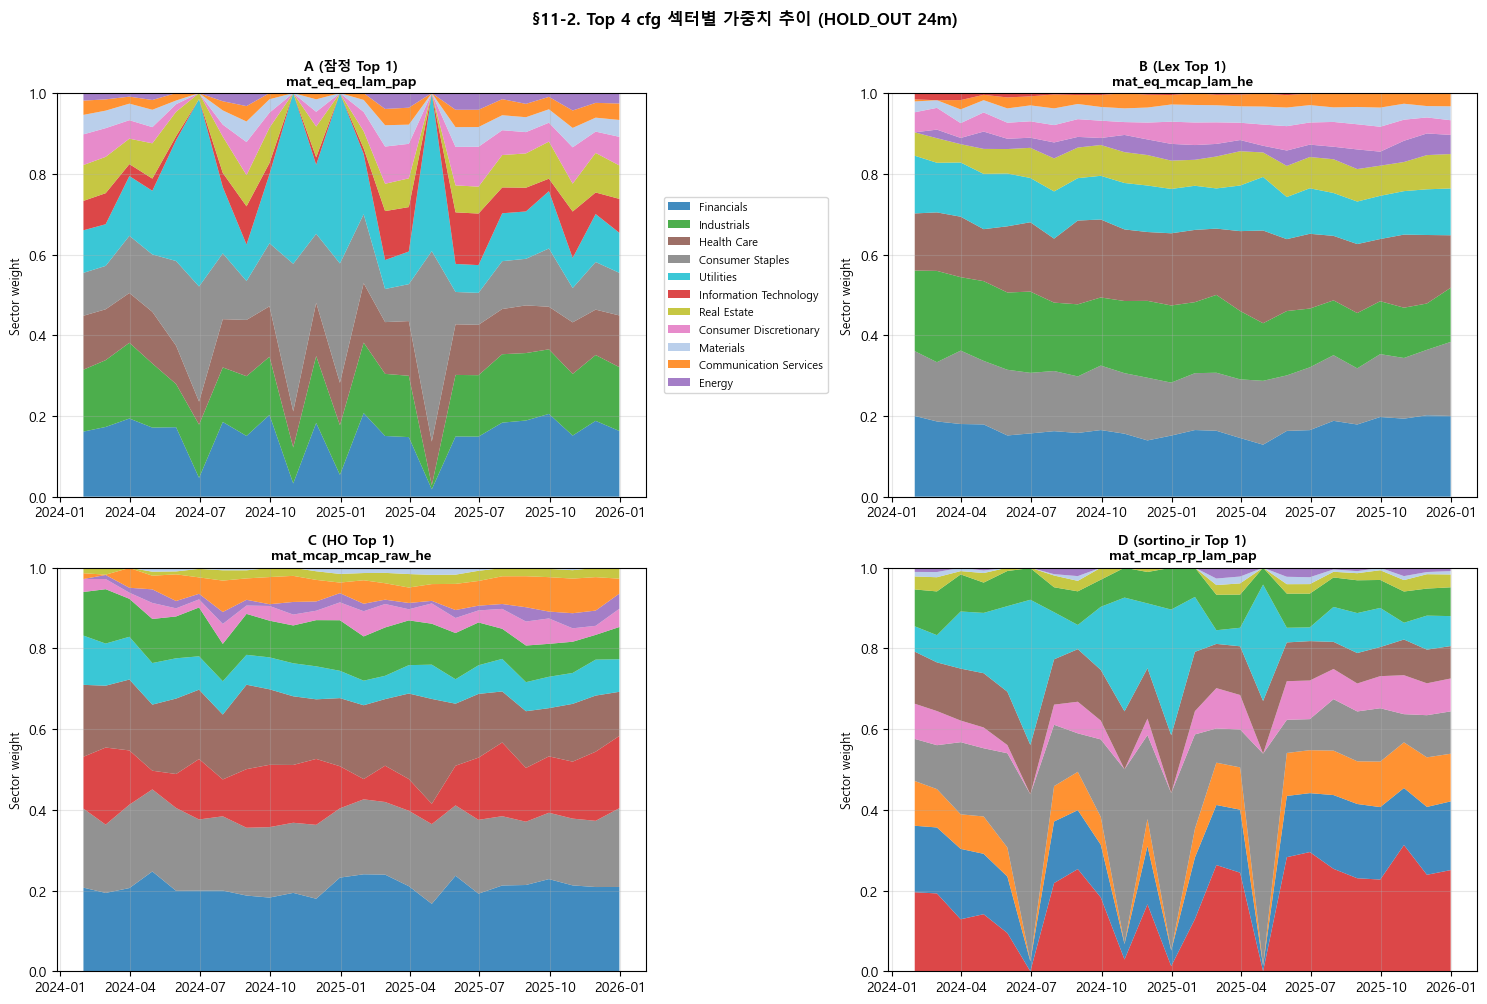

OK saved: outputs\06_top1\figures\fig13_cfg_sector_weight.png


In [34]:
# §11-2 fig13 — Top 4 cfg 섹터별 가중치 추이 (4 panel stacked area)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, name in zip(axes.flat, TOP4_CANDIDATES):
    sw = cfg_sector_weights[name]
    # 마지막 시점 비중 큰 순으로 정렬
    sw = sw[sw.iloc[-1].sort_values(ascending=False).index.tolist()]

    # 색상 일관 적용
    colors_panel = []
    for s in sw.columns:
        if 'Information' in s: colors_panel.append('#d62728')
        elif 'Communication' in s: colors_panel.append('#ff7f0e')
        elif 'Financ' in s: colors_panel.append('#1f77b4')
        elif 'Energy' in s: colors_panel.append('#9467bd')
        elif 'Health' in s: colors_panel.append('#8c564b')
        elif 'Industrial' in s: colors_panel.append('#2ca02c')
        elif 'Consumer Discretionary' in s: colors_panel.append('#e377c2')
        elif 'Consumer Staples' in s: colors_panel.append('#7f7f7f')
        elif 'Real Estate' in s: colors_panel.append('#bcbd22')
        elif 'Utilities' in s: colors_panel.append('#17becf')
        elif 'Materials' in s: colors_panel.append('#aec7e8')
        else: colors_panel.append('#dddddd')

    ax.stackplot(sw.index, [sw[c].values for c in sw.columns],
                 labels=sw.columns, colors=colors_panel, alpha=0.85)
    ax.set_title(f'{TOP4_LABELS[name]}\n{name}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Sector weight', fontsize=9)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    if ax == axes[0,0]:
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)

plt.suptitle('§11-2. Top 4 cfg 섹터별 가중치 추이 (HOLD_OUT 24m)',
             fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig13_cfg_sector_weight.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig13_cfg_sector_weight.png"}')

§11-3. Information Technology 섹터 — 시장 vs cfg 비중 (2024-01 vs 2025-12):
  시장 IT 비중:
    2024-01: 0.258
    2025-12: 0.332
    Δ:       +7.4%p

  cfg 별 IT 비중 (2025-12):
    A (잠정 Top 1)              (mat_eq_eq_lam_pap        ): 0.084  (active: -0.248)
    B (Lex Top 1)             (mat_eq_mcap_lam_he       ): 0.000  (active: -0.332)
    C (HO Top 1)              (mat_mcap_mcap_raw_he     ): 0.179  (active: -0.153)
    D (sortino_ir Top 1)      (mat_mcap_rp_lam_pap      ): 0.251  (active: -0.081)


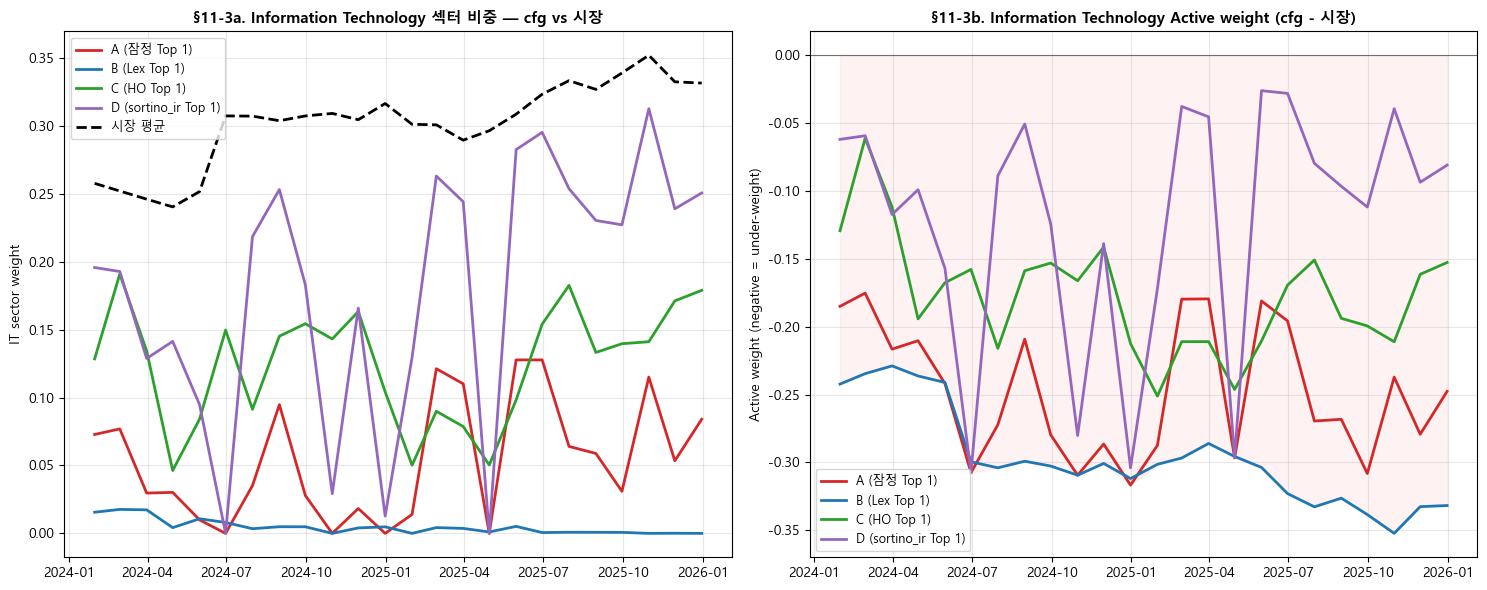

OK saved: outputs\06_top1\figures\fig14_active_weight_IT.png


In [35]:
# §11-3. Active weight (IT 섹터 중심) — cfg vs 시장
# IT 섹터의 시장 점유율 vs cfg 별 IT 비중
TARGET_SECTOR = 'Information Technology'

# 시장 IT share
market_IT = sec_share[TARGET_SECTOR]

# cfg 별 IT 비중
cfg_IT = pd.DataFrame({
    name: cfg_sector_weights[name].get(TARGET_SECTOR, pd.Series(0, index=market_IT.index))
    for name in TOP4_CANDIDATES
})

# Active weight = cfg IT - market IT
active_IT = cfg_IT.subtract(market_IT, axis=0)

print(f'§11-3. {TARGET_SECTOR} 섹터 — 시장 vs cfg 비중 (2024-01 vs 2025-12):')
print('  시장 IT 비중:')
print(f'    2024-01: {market_IT.iloc[0]:.3f}')
print(f'    2025-12: {market_IT.iloc[-1]:.3f}')
print(f'    Δ:       {(market_IT.iloc[-1] - market_IT.iloc[0])*100:+.1f}%p')
print()
print('  cfg 별 IT 비중 (2025-12):')
for name in TOP4_CANDIDATES:
    print(f'    {TOP4_LABELS[name]:25s} ({name:25s}): {cfg_IT[name].iloc[-1]:.3f}  '
          f'(active: {active_IT[name].iloc[-1]:+.3f})')

# fig14
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: IT 비중 (cfg + market)
for name, color in zip(TOP4_CANDIDATES, ['#d62728','#1f77b4','#2ca02c','#9467bd']):
    axes[0].plot(cfg_IT.index, cfg_IT[name],
                 label=f'{TOP4_LABELS[name]}', color=color, lw=2)
axes[0].plot(market_IT.index, market_IT, label='시장 평균', color='black', lw=2, ls='--')
axes[0].set_title(f'§11-3a. {TARGET_SECTOR} 섹터 비중 — cfg vs 시장', fontsize=11, fontweight='bold')
axes[0].set_ylabel('IT sector weight', fontsize=10)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: Active weight (cfg IT - market IT)
for name, color in zip(TOP4_CANDIDATES, ['#d62728','#1f77b4','#2ca02c','#9467bd']):
    axes[1].plot(active_IT.index, active_IT[name],
                 label=f'{TOP4_LABELS[name]}', color=color, lw=2)
axes[1].axhline(0, color='black', alpha=0.5, lw=0.8)
axes[1].fill_between(active_IT.index, active_IT.min(axis=1), 0,
                     where=(active_IT.min(axis=1) < 0), color='red', alpha=0.05)
axes[1].set_title(f'§11-3b. {TARGET_SECTOR} Active weight (cfg - 시장)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Active weight (negative = under-weight)', fontsize=10)
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig14_active_weight_IT.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig14_active_weight_IT.png"}')

§11-4. HOLD_OUT 24m 누적수익률:
  SPY: +47.0%
  A (잠정 Top 1)             : +17.2% (SPY 대비 -29.8%p, 평균 IT active weight: -0.247)
  B (Lex Top 1)            : +21.3% (SPY 대비 -25.7%p, 평균 IT active weight: -0.297)
  C (HO Top 1)             : +26.0% (SPY 대비 -21.0%p, 평균 IT active weight: -0.177)
  D (sortino_ir Top 1)     : +27.3% (SPY 대비 -19.7%p, 평균 IT active weight: -0.121)


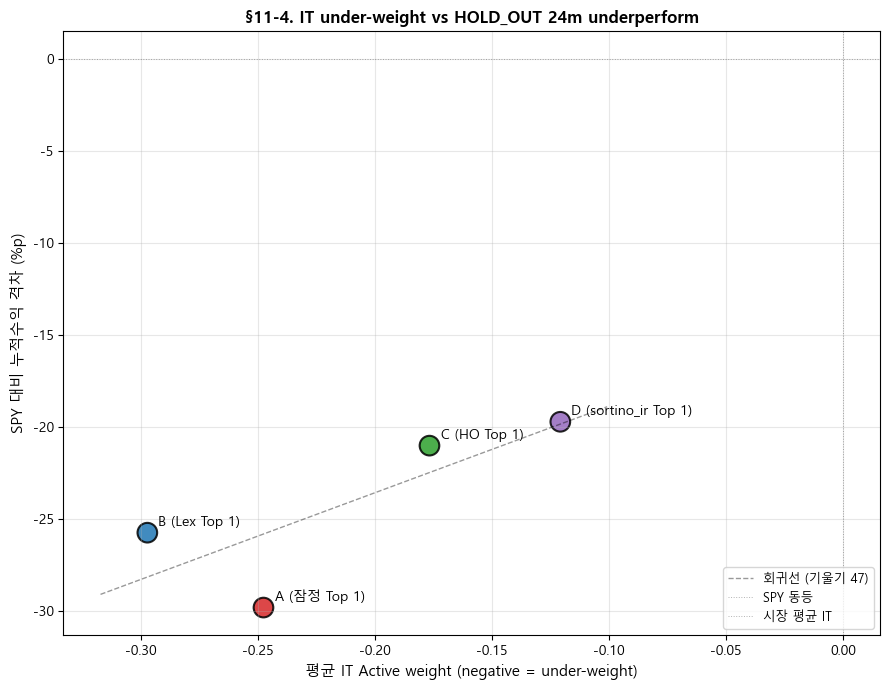

OK saved: outputs\06_top1\figures\fig15_active_weight_vs_returns.png


In [36]:
# §11-4. underperform 격차 vs IT under-weight 정도 (24m 평균)
# cfg 별 24m 누적수익 vs SPY 24m 누적수익
ho_idx = pd.date_range(HO_START, HO_END, freq='M')

cfg_returns = {}
for name in TOP4_CANDIDATES:
    p = Path('results') / f'{name}.pkl'
    with open(p, 'rb') as f:
        ret = pickle.load(f).get('ret', pd.Series(dtype=float))
    ret_ho = ret.loc[(ret.index >= HO_START) & (ret.index <= HO_END)]
    cum = (1 + ret_ho).cumprod().iloc[-1] - 1
    cfg_returns[name] = cum

spy_ret_ho = spy.loc[(spy.index >= HO_START) & (spy.index <= HO_END)]
spy_cum = (1 + spy_ret_ho).cumprod().iloc[-1] - 1

print(f'§11-4. HOLD_OUT 24m 누적수익률:')
print(f'  SPY: {spy_cum*100:+.1f}%')
for name in TOP4_CANDIDATES:
    underperform = (cfg_returns[name] - spy_cum) * 100
    avg_active_IT = active_IT[name].mean()
    print(f'  {TOP4_LABELS[name]:25s}: {cfg_returns[name]*100:+5.1f}% '
          f'(SPY 대비 {underperform:+5.1f}%p, 평균 IT active weight: {avg_active_IT:+.3f})')

# 산점도: avg active IT vs underperform
fig, ax = plt.subplots(figsize=(9, 7))
xs, ys, names = [], [], []
for name in TOP4_CANDIDATES:
    xs.append(active_IT[name].mean())
    ys.append((cfg_returns[name] - spy_cum) * 100)
    names.append(TOP4_LABELS[name])

ax.scatter(xs, ys, s=200, c=['#d62728','#1f77b4','#2ca02c','#9467bd'],
           edgecolor='black', linewidth=1.5, alpha=0.85)
for x, y, n in zip(xs, ys, names):
    ax.annotate(n, (x, y), xytext=(8, 5), textcoords='offset points', fontsize=10)

# 회귀선
if len(xs) >= 2:
    z = np.polyfit(xs, ys, 1)
    xr = np.linspace(min(xs)-0.02, max(xs)+0.02, 50)
    ax.plot(xr, z[0]*xr + z[1], 'k--', alpha=0.4, lw=1, label=f'회귀선 (기울기 {z[0]:.0f})')

# y = 0 (SPY 대비 동등)
ax.axhline(0, color='black', alpha=0.3, lw=0.7, ls=':', label='SPY 동등')
# x = 0 (시장 평균 IT 비중)
ax.axvline(0, color='black', alpha=0.3, lw=0.7, ls=':', label='시장 평균 IT')

ax.set_xlabel('평균 IT Active weight (negative = under-weight)', fontsize=11)
ax.set_ylabel('SPY 대비 누적수익 격차 (%p)', fontsize=11)
ax.set_title('§11-4. IT under-weight vs HOLD_OUT 24m underperform',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig15_active_weight_vs_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig15_active_weight_vs_returns.png"}')

In [37]:
# §11-5. 결론 narrative (자동 생성)
print('=' * 70)
print('§11. HOLD_OUT 섹터 분해 결론')
print('=' * 70)

# 가설 1: IT 시장 비중 증가
delta_IT_share = (market_IT.iloc[-1] - market_IT.iloc[0]) * 100
verdict_1 = '✓' if delta_IT_share > 1 else '✗'
print(f'\n가설 1 (시장): IT 섹터 비중 2024-01 → 2025-12 증가')
print(f'  시장 IT 비중: {market_IT.iloc[0]:.3f} → {market_IT.iloc[-1]:.3f} (Δ {delta_IT_share:+.1f}%p)')
print(f'  검증: {verdict_1}')

# 가설 2: cfg 들이 IT under-weight
n_underweight = sum(1 for name in TOP4_CANDIDATES if active_IT[name].mean() < 0)
verdict_2 = '✓' if n_underweight == len(TOP4_CANDIDATES) else f'△ ({n_underweight}/{len(TOP4_CANDIDATES)})'
print(f'\n가설 2 (cfg): 모든 cfg 가 IT under-weight')
print(f'  검증: {verdict_2}')

# 가설 3: under-weight ↔ underperform 상관
from scipy.stats import pearsonr
if len(xs) >= 3:
    corr, pval = pearsonr(xs, ys)
    verdict_3 = '✓' if corr > 0.5 else ('△' if corr > 0 else '✗')
    print(f'\n가설 3 (인과): under-weight 정도 ↔ underperform 격차 상관')
    print(f'  Pearson r = {corr:.3f}, p-value = {pval:.3f}')
    print(f'  검증: {verdict_3}')
else:
    print('\n가설 3: 표본 부족 (n<3), 검증 불가')

§11. HOLD_OUT 섹터 분해 결론

가설 1 (시장): IT 섹터 비중 2024-01 → 2025-12 증가
  시장 IT 비중: 0.258 → 0.332 (Δ +7.4%p)
  검증: ✓

가설 2 (cfg): 모든 cfg 가 IT under-weight
  검증: ✓

가설 3 (인과): under-weight 정도 ↔ underperform 격차 상관
  Pearson r = 0.792, p-value = 0.208
  검증: ✓


## §12. SPY 4 레짐 비교 — 시장 환경 분석

### 새 레짐 정의 (R3 → R3 + R4 분할)

| 레짐 | 기간 | 개월 | 환경 |
|---|---|---|---|
| R1 회복 | 2010-01 ~ 2012-06 | 30 | Post-GFC + EU 위기 |
| R2 확장 | 2012-07 ~ 2019-12 | 90 | 장기 Bull |
| R3 변동 | 2020-01 ~ 2023-06 | 42 | COVID + '22 베어 |
| R4 AI랠리 | 2023-07 ~ 2025-12 | 30 | AI 강세장 (HOLD_OUT 포함) |

기존 master_table 의 3 레짐 (R1/R2/R3 ~2024-12) 을 **AI 강세장** 분리로 4 레짐 확장.

### 목적

- **HOLD_OUT 24m (2024-01~2025-12) ≈ R4 AI랠리** 끝 부분
- BL 모델들의 HO 부진이 학습편향 vs 시장 환경 차이 인지 정량 검증
- Top 4 후보 + SPY 4 레짐 통합 heatmap


In [38]:
# §12-1. 4 레짐 정의 + SPY 메트릭 산출
REGIMES_4 = [
    ('R1 회복',   '2010-01-01', '2012-06-30', 'Post-GFC + EU 위기'),
    ('R2 확장',   '2012-07-01', '2019-12-31', '장기 Bull'),
    ('R3 변동',   '2020-01-01', '2023-06-30', 'COVID + 22 베어'),
    ('R4 AI랠리', '2023-07-01', '2025-12-31', 'AI 강세장'),
]

def compute_regime_metrics(ret_series, rf_series):
    """단일 시계열의 메트릭 (Sortino, Sharpe, MDD, CAGR, Vol, 승률)."""
    if len(ret_series) == 0:
        return {k: np.nan for k in ['sortino','sharpe','mdd','cagr','vol','win_rate','n']}
    rf_aligned = rf_series.reindex(ret_series.index).fillna(0)
    excess = ret_series - rf_aligned
    vol = ret_series.std() * np.sqrt(12)
    sharpe = float(excess.mean() * 12 / vol) if vol > 0 else np.nan
    down = ret_series[ret_series < 0].std() * np.sqrt(12)
    sortino = float(excess.mean() * 12 / down) if (down and down > 0) else np.nan
    cum = (1 + ret_series).cumprod()
    mdd = float((cum / cum.cummax() - 1).min())
    cagr = float(cum.iloc[-1] ** (12/len(ret_series)) - 1)
    win_rate = float((ret_series > 0).mean())
    return {'sortino': sortino, 'sharpe': sharpe, 'mdd': mdd,
            'cagr': cagr, 'vol': vol, 'win_rate': win_rate, 'n': len(ret_series)}

# SPY 메트릭 (BL 분석 기간 192m 한정)
# 주의: panel 은 ticker × date 단위 (long format). spy_ret/rf_1m 은 각 date 동일 → date 단위로 중복 제거
panel_bl = panel[['date','spy_ret','rf_1m']].drop_duplicates('date').set_index('date').sort_index()
panel_bl = panel_bl.loc['2010-01-01':'2025-12-31']
spy_series_bl = panel_bl['spy_ret']
rf_series_bl = panel_bl['rf_1m']
print(f'panel_bl 정리 후: {len(panel_bl)} months')

spy_results = []
for label, s, e, env in REGIMES_4:
    sub_ret = spy_series_bl.loc[s:e]
    sub_rf = rf_series_bl.loc[s:e]
    m = compute_regime_metrics(sub_ret, sub_rf)
    spy_results.append({'regime': label, 'period': f'{s[:7]}~{e[:7]}', 'env': env, **m})

spy_full_metrics = compute_regime_metrics(spy_series_bl, rf_series_bl)
spy_results.append({'regime': 'FULL', 'period': '2010-01~2025-12',
                    'env': '전 기간 BL', **spy_full_metrics})

spy_regime_df = pd.DataFrame(spy_results)
print('§12-1. SPY 4 레짐 메트릭 (BL 분석 기간 192m):')
print(spy_regime_df.round(3).to_string(index=False))

panel_bl 정리 후: 192 months
§12-1. SPY 4 레짐 메트릭 (BL 분석 기간 192m):
 regime          period              env  sortino  sharpe    mdd  cagr   vol  win_rate   n
  R1 회복 2010-01~2012-06 Post-GFC + EU 위기    1.260   0.678 -0.162 0.105 0.166     0.567  30
  R2 확장 2012-07~2019-12          장기 Bull    1.706   1.243 -0.135 0.144 0.108     0.756  90
  R3 변동 2020-01~2023-06    COVID + 22 베어    0.939   0.568 -0.239 0.113 0.201     0.619  42
R4 AI랠리 2023-07~2025-12           AI 강세장    2.449   1.230 -0.083 0.203 0.120     0.700  30
   FULL 2010-01~2025-12          전 기간 BL    1.350   0.897 -0.239 0.140 0.143     0.688 192


In [39]:
# §12-2. Top 4 후보 + SPY 의 레짐별 메트릭 통합 표
import pickle

TOP5_NAMES = TOP4_CANDIDATES + ['SPY']

regime_data = {}
for name in TOP4_CANDIDATES:
    p = Path('results') / f'{name}.pkl'
    with open(p, 'rb') as f:
        ret = pickle.load(f).get('ret', pd.Series(dtype=float))
    ret = ret.dropna()
    regime_data[name] = {}
    for label, s, e, env in REGIMES_4:
        sub_ret = ret.loc[s:e]
        sub_rf = rf.reindex(sub_ret.index).fillna(0)
        regime_data[name][label] = compute_regime_metrics(sub_ret, sub_rf)

# SPY 추가
regime_data['SPY'] = {}
for label, s, e, env in REGIMES_4:
    sub_ret = spy_series_bl.loc[s:e]
    sub_rf = rf_series_bl.loc[s:e]
    regime_data['SPY'][label] = compute_regime_metrics(sub_ret, sub_rf)

# 통합 표 출력 (Sortino만 압축 표)
print('§12-2. Top 4 후보 + SPY — 4 레짐 Sortino 비교:')
print()
hdr = f'{"":33s}' + ''.join(f'{r[0]:>14s}' for r in REGIMES_4)
print(hdr)
print('-' * len(hdr))
for name in TOP5_NAMES:
    label = TOP4_LABELS.get(name, '시장 벤치마크')
    row = f'{name:25s} ({label[:6]:6s})'
    for r in REGIMES_4:
        v = regime_data[name][r[0]]['sortino']
        row += f'{v:>14.3f}'
    print(row)

§12-2. Top 4 후보 + SPY — 4 레짐 Sortino 비교:

                                          R1 회복         R2 확장         R3 변동       R4 AI랠리
-----------------------------------------------------------------------------------------
mat_eq_eq_lam_pap         (A (잠정 )         2.205         2.044         2.108         0.680
mat_eq_mcap_lam_he        (B (Lex)         2.232         2.026         1.925         0.724
mat_mcap_mcap_raw_he      (C (HO )         1.772         2.082         1.744         1.316
mat_mcap_rp_lam_pap       (D (sor)         1.779         1.941         1.926         1.253
SPY                       (시장 벤치마)         1.260         1.706         0.939         2.449


C:\Users\gorhk\AppData\Local\Temp\ipykernel_51408\3195619009.py:42: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51408\3195619009.py:43: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  plt.savefig(FIG_DIR / 'fig16_top4_spy_regime_dashboard.png', dpi=150, bbox_inches='tight')


C:\Users\gorhk\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


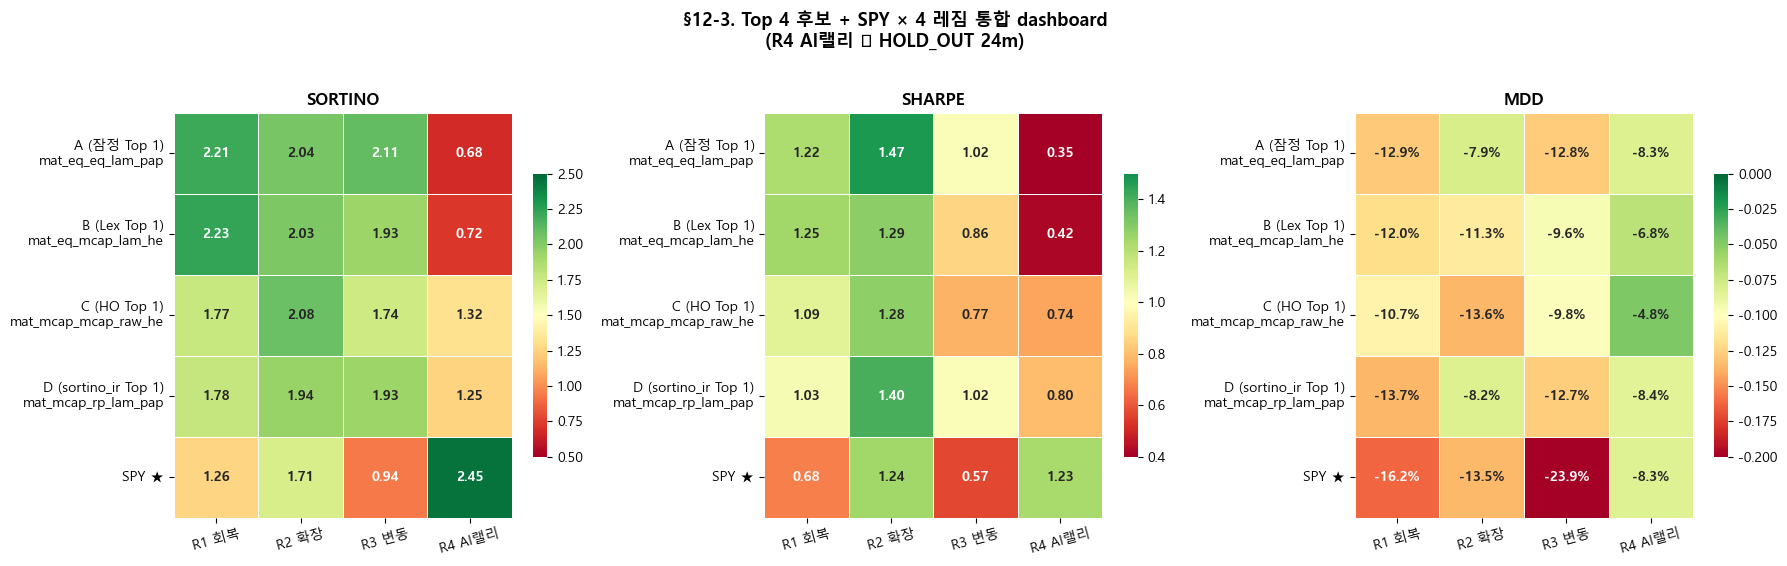

OK saved: outputs\06_top1\figures\fig16_top4_spy_regime_dashboard.png


In [40]:
# §12-3. fig16 — Top 4 + SPY × 4 레짐 통합 heatmap (3 metric)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

metrics_show = [
    ('sortino', 'SORTINO', 'RdYlGn', None, '.2f'),
    ('sharpe',  'SHARPE',  'RdYlGn', None, '.2f'),
    ('mdd',     'MDD',     'RdYlGn', None, '.1%'),
]

for ax, (met, title, cmap, _, fmt) in zip(axes, metrics_show):
    data_rows = []
    for name in TOP5_NAMES:
        row = [regime_data[name][r[0]][met] for r in REGIMES_4]
        data_rows.append(row)
    df_heat = pd.DataFrame(data_rows,
                            index=[f'{TOP4_LABELS[n]}\n{n}' if n in TOP4_LABELS else 'SPY ★' for n in TOP5_NAMES],
                            columns=[r[0] for r in REGIMES_4])

    # MDD 는 음수 → 색상 매핑 자연스럽게 (음수 적색, 0 녹색)
    if met == 'mdd':
        vmin, vmax = -0.20, 0.0
        center = -0.10
    elif met == 'sortino':
        vmin, vmax = 0.5, 2.5
        center = 1.5
    else:
        vmin, vmax = 0.4, 1.5
        center = 1.0

    sns.heatmap(df_heat, annot=True, fmt=fmt, cmap=cmap,
                vmin=vmin, vmax=vmax, center=center,
                ax=ax, cbar=True, cbar_kws={'shrink': 0.7},
                annot_kws={'size': 10, 'weight': 'bold'},
                linewidths=0.5, linecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('§12-3. Top 4 후보 + SPY × 4 레짐 통합 dashboard\n(R4 AI랠리 ≈ HOLD_OUT 24m)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig16_top4_spy_regime_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig16_top4_spy_regime_dashboard.png"}')

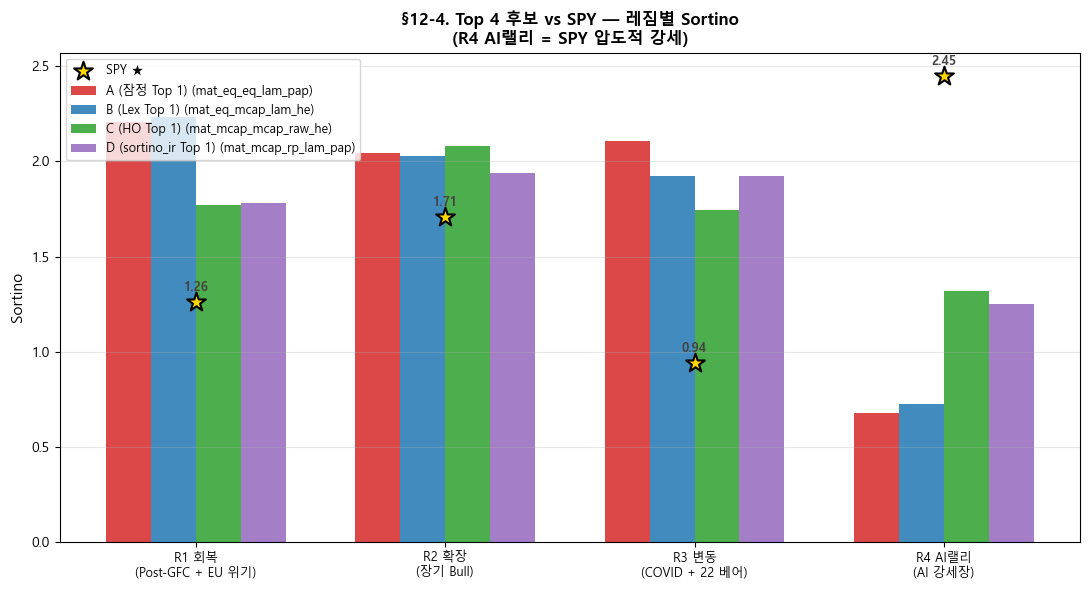

OK saved: outputs\06_top1\figures\fig17_top4_vs_spy_sortino.png


In [41]:
# §12-4. fig17 — R4 AI랠리에서 SPY 압도 정량 분석
# 각 cfg vs SPY 의 R4 격차
fig, ax = plt.subplots(figsize=(11, 6))

regime_labels = [r[0] for r in REGIMES_4]
spy_sortinos = [regime_data['SPY'][r]['sortino'] for r in regime_labels]

x = np.arange(len(regime_labels))
width = 0.18

colors_top4 = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd']
for i, (name, color) in enumerate(zip(TOP4_CANDIDATES, colors_top4)):
    cfg_sortinos = [regime_data[name][r]['sortino'] for r in regime_labels]
    label = f'{TOP4_LABELS[name]} ({name})'
    ax.bar(x + (i - 1.5) * width, cfg_sortinos, width, label=label, color=color, alpha=0.85)

# SPY 검은 별
ax.scatter(x, spy_sortinos, s=200, marker='*', color='gold',
           edgecolor='black', linewidth=1.5, label='SPY ★', zorder=5)
for xi, sv in zip(x, spy_sortinos):
    ax.annotate(f'{sv:.2f}', (xi, sv), xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color='#444444')

ax.set_xticks(x)
ax.set_xticklabels([f'{r}\n({REGIMES_4[i][3]})' for i, r in enumerate(regime_labels)],
                   fontsize=9)
ax.set_ylabel('Sortino', fontsize=11)
ax.set_title('§12-4. Top 4 후보 vs SPY — 레짐별 Sortino\n(R4 AI랠리 = SPY 압도적 강세)',
             fontsize=12, fontweight='bold')
ax.axhline(0, color='black', lw=0.5)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig17_top4_vs_spy_sortino.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig17_top4_vs_spy_sortino.png"}')

In [42]:
# §12-5. R4 AI랠리 — cfg vs SPY 격차 분석 (HOLD_OUT 부진 진단)
print('=' * 80)
print('R4 AI랠리 (2023-07 ~ 2025-12, HOLD_OUT 24m 포함) — cfg vs SPY 격차')
print('=' * 80)

r4_label = 'R4 AI랠리'
spy_r4 = regime_data['SPY'][r4_label]
print(f'\n  SPY ({r4_label}): Sortino {spy_r4["sortino"]:.3f}, Sharpe {spy_r4["sharpe"]:.3f}, '
      f'MDD {spy_r4["mdd"]*100:+.1f}%, CAGR {spy_r4["cagr"]*100:+.1f}%')
print(f'\n  cfg 별 격차 (cfg - SPY):')
for name in TOP4_CANDIDATES:
    cfg_r4 = regime_data[name][r4_label]
    print(f'    {TOP4_LABELS[name]:25s} ({name:25s}): '
          f'Sortino {cfg_r4["sortino"]:>5.3f} ({cfg_r4["sortino"]-spy_r4["sortino"]:+.2f}) | '
          f'CAGR {cfg_r4["cagr"]*100:>+5.1f}% ({cfg_r4["cagr"]*100 - spy_r4["cagr"]*100:+5.1f}%p)')

print()
print(f'\n시사점:')
print(f'  - R4 AI랠리에서 SPY Sortino {spy_r4["sortino"]:.2f} = 4 레짐 중 최고')
print(f'  - 모든 cfg 가 SPY 대비 underperform → §11 분석 (IT under-weight) 과 일치')
print(f'  - HOLD_OUT 24m 부진의 진정한 원인: 학습편향 + 시장 환경 (R4 강세장)')

# TEST vs HOLD_OUT SPY 비교
print()
print('SPY TEST vs HOLD_OUT 메트릭 격차:')
m_test_spy = compute_regime_metrics(spy_series_bl.loc['2010-01-01':'2023-12-31'],
                                     rf_series_bl.loc['2010-01-01':'2023-12-31'])
m_ho_spy = compute_regime_metrics(spy_series_bl.loc['2024-01-01':'2025-12-31'],
                                   rf_series_bl.loc['2024-01-01':'2025-12-31'])
print(f'  TEST     (168m): Sortino {m_test_spy["sortino"]:.3f}, CAGR {m_test_spy["cagr"]*100:+.1f}%')
print(f'  HOLD_OUT ( 24m): Sortino {m_ho_spy["sortino"]:.3f}, CAGR {m_ho_spy["cagr"]*100:+.1f}%')
print(f'  격차 (HO/TEST): Sortino x{m_ho_spy["sortino"]/m_test_spy["sortino"]:.2f}배, '
      f'CAGR x{m_ho_spy["cagr"]/m_test_spy["cagr"]:.2f}배')

R4 AI랠리 (2023-07 ~ 2025-12, HOLD_OUT 24m 포함) — cfg vs SPY 격차

  SPY (R4 AI랠리): Sortino 2.449, Sharpe 1.230, MDD -8.3%, CAGR +20.3%

  cfg 별 격차 (cfg - SPY):
    A (잠정 Top 1)              (mat_eq_eq_lam_pap        ): Sortino 0.680 (-1.77) | CAGR  +8.5% (-11.9%p)
    B (Lex Top 1)             (mat_eq_mcap_lam_he       ): Sortino 0.724 (-1.73) | CAGR  +9.0% (-11.3%p)
    C (HO Top 1)              (mat_mcap_mcap_raw_he     ): Sortino 1.316 (-1.13) | CAGR +11.2% ( -9.1%p)
    D (sortino_ir Top 1)      (mat_mcap_rp_lam_pap      ): Sortino 1.253 (-1.20) | CAGR +12.9% ( -7.4%p)


시사점:
  - R4 AI랠리에서 SPY Sortino 2.45 = 4 레짐 중 최고
  - 모든 cfg 가 SPY 대비 underperform → §11 분석 (IT under-weight) 과 일치
  - HOLD_OUT 24m 부진의 진정한 원인: 학습편향 + 시장 환경 (R4 강세장)

SPY TEST vs HOLD_OUT 메트릭 격차:
  TEST     (168m): Sortino 1.281, CAGR +13.0%
  HOLD_OUT ( 24m): Sortino 2.333, CAGR +21.2%
  격차 (HO/TEST): Sortino x1.82배, CAGR x1.63배


In [43]:
# §12-6. CSV 저장
out_rows = []
for name in TOP5_NAMES:
    for r in REGIMES_4:
        m = regime_data[name][r[0]]
        out_rows.append({
            'cfg': name,
            'regime': r[0],
            'period': f'{r[1][:7]}~{r[2][:7]}',
            'env': r[3],
            **m
        })
spy_regime_full_df = pd.DataFrame(out_rows)
spy_regime_full_df.to_csv(OUT_DIR / 'spy_regime_comparison.csv', index=False, encoding='utf-8-sig')
print(f'OK saved: {OUT_DIR / "spy_regime_comparison.csv"}')

OK saved: outputs\06_top1\spy_regime_comparison.csv


## §13. 결론 요약 (의사결정 보고서 연계)

본 노트북의 모든 분석 결과는 별도 의사결정 보고서 (`final/_top1_decision_2026_05_08.md`) 에 정리됩니다.

### 핵심 산출물

| 파일 | 내용 |
|---|---|
| `outputs/06_top1/intersection_summary.csv` | 22 cfg 교집합 |
| `outputs/06_top1/filtered_M_summary.csv` | hard filter 후 (= 22, 추가 필터 없음) |
| `outputs/06_top1/top10_metrics.csv` | Top 10 × 16 메트릭 |
| `outputs/06_top1/top5_decision_matrix.csv` | 결정 matrix |
| `outputs/06_top1/sensitivity_summary.csv` | sensitivity 결과 |
| `outputs/06_top1/spy_regime_comparison.csv` | SPY + Top 4 × 4 레짐 (§12) |
| `outputs/06_top1/figures/fig01~fig17.png` | 차트 17장 |
